<a href="https://colab.research.google.com/github/aliciawijaya98/aliciawijaya98.github.io/blob/master/Final_Project_Alpha_Team_Seller_Churn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Seller Churn Prediction in Brazilian E-Commerce Using Machine Learning

**Author:** Jefferson, Alicia, Azhar
**Dataset:** Brazilian E-Commerce Public Dataset by Olist  
**Period:** 2016–2018

In [ ]:
# ============================================================
# Library Imports
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

from sklearn.model_selection import (train_test_split, StratifiedKFold,
                                     RandomizedSearchCV, cross_val_score,
                                     learning_curve)
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, average_precision_score,
                             confusion_matrix, classification_report,
                             roc_curve, precision_recall_curve)
import shap

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.2f}'.format)
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11

print('Libraries imported successfully.')

Libraries imported successfully.


In [ ]:
# ============================================================
# Load All Datasets
# ============================================================

from google.colab import drive
import pandas as pd

drive.mount('/content/drive')

DATA_PATH = '/content/drive/MyDrive/OlistData/'

customers   = pd.read_csv(f'{DATA_PATH}olist_customers_dataset.csv')
orders      = pd.read_csv(f'{DATA_PATH}olist_orders_dataset.csv')
order_items = pd.read_csv(f'{DATA_PATH}olist_order_items_dataset.csv')
payments    = pd.read_csv(f'{DATA_PATH}olist_order_payments_dataset.csv')
reviews     = pd.read_csv(f'{DATA_PATH}olist_order_reviews_dataset.csv')
products    = pd.read_csv(f'{DATA_PATH}olist_products_dataset.csv')
sellers     = pd.read_csv(f'{DATA_PATH}olist_sellers_dataset.csv')
geolocation = pd.read_csv(f'{DATA_PATH}olist_geolocation_dataset.csv')
category_translation = pd.read_csv(f'{DATA_PATH}product_category_name_translation.csv')

print('All datasets loaded successfully.')

Mounted at /content/drive
All datasets loaded successfully.


---
## 1. Introduction

### 1.1 Background

The rapid growth of e-commerce has intensified competition among online marketplaces, making seller retention an increasingly important business priority. Unlike traditional retailers, marketplace platforms rely on third-party sellers to provide product variety, maintain inventory availability, and generate transaction revenue. Therefore, the sustainability of a marketplace depends not only on attracting customers but also on retaining active sellers.

Seller churn, defined as the discontinuation of selling activities on the platform, can negatively impact business performance by reducing transaction volume, limiting product assortment, and increasing the cost of acquiring new sellers. In the context of Brazilian e-commerce, where marketplace penetration is growing rapidly but seller onboarding costs remain significant, understanding what drives seller attrition is essential for supporting long-term marketplace growth.

This project uses the Olist Brazilian E-Commerce Public Dataset, which contains approximately 100,000 real transactions from 2016 to 2018 involving 3,095 registered sellers across 23 Brazilian states. The dataset provides a comprehensive view of seller activity, including transaction frequency, revenue, customer reviews, delivery performance, and product catalog diversity. All of which can serve as early indicators of churn risk.

### 1.2 Problem Statement

Seller churn can negatively affect marketplace performance by decreasing transaction revenue and reducing the availability and diversity of products offered to customers. Since sellers often become inactive without prior warning, e-commerce companies face challenges in implementing timely retention strategies.

From the dataset, preliminary analysis reveals that over 50% of sellers who were active before mid-2018 had no transactions in the following 90 days. Churned sellers averaged only 12.7 orders and R\$2,153 in total revenue, compared to active sellers who averaged 63.4 orders and R\$8,061 — indicating that lower engagement and revenue are strongly associated with attrition.

Therefore, there is a need for a predictive model that can identify sellers at risk of churn before they leave the platform, enabling proactive retention interventions rather than reactive measures after the seller has already gone inactive.

### 1.3 Goal

The objective of this project is to develop a machine learning model to predict seller churn using historical transaction data from the Olist Brazilian E-Commerce Public Dataset. By identifying sellers with a high risk of churn, the model can support e-commerce companies in implementing proactive retention strategies, reducing potential revenue loss, and improving the sustainability of the seller ecosystem.

### 1.4 Analytical Approach (INI NANTI AJA DIMASUKINNYA PAS UDAH CLEAR STEPNYA MAU GIMANA)

---
## 2. Data Understanding

### 2.1 Dataset Overview

This project utilizes the Brazilian E-Commerce Public Dataset by Olist, a publicly available collection of real transactional records from Brazilian online marketplaces.

For a **seller churn** use case, the focus shifts from the customer journey to **seller-side transactional behavior over time** — i.e. how consistently a seller receives orders, how well they perform operationally, and whether that activity eventually stops. Of the 9 available tables, **7 are relevant** and used in this analysis; 2 are excluded as they describe the buyer side rather than the seller side.

| Table | Records | Used? | Relevance to Seller Churn |
|-------|--------:|:---:|-------------|
| `olist_order_items_dataset` | 112,650 | ✅ | **Core table** — links every transaction to a `seller_id`; the backbone for measuring seller activity, frequency, and recency |
| `olist_orders_dataset` | 99,441 | ✅ | Provides order status & timestamps — needed to determine *when* a seller's last transaction occurred and whether orders were fulfilled or canceled |
| `olist_sellers_dataset` | 3,095 | ✅ | Seller attributes (location) — candidate features and the entity-level table the churn label is built around |
| `olist_products_dataset` | 32,951 | ✅ | Product attributes sold by each seller — used to derive catalog diversity features (e.g. number of distinct categories) |
| `product_category_name_translation` | 71 | ✅ | Translates product categories (PT → EN) for readability |
| `olist_order_payments_dataset` | 103,886 | ✅ | Payment values — basis for *monetary* (revenue) features per seller |
| `olist_order_reviews_dataset` | 104,719 | ✅ | Review scores — proxy for seller service quality, a potential churn driver |
| `olist_customers_dataset` | 99,441 | ❌ | Describes buyer identity/location only — not informative about seller behavior |
| `olist_geolocation_dataset` | 1,000,163 | ❌ | Extremely granular zip-code coordinates; seller location is already sufficiently captured in `olist_sellers_dataset` |

These 7 tables are linked through `order_id`, `product_id`, and most importantly **`seller_id`** — the key around which all transactional history is aggregated to build seller-level recency, frequency, monetary (RFM), and service-quality features, and ultimately the churn label itself.

### 2.2 Dataset Structure

In [ ]:
# ============================================================
# Dataset Summary Table
# ============================================================

datasets = {
    'orders': orders,
    'order_items': order_items,
    'payments': payments,
    'reviews': reviews,
    'products': products,
    'sellers': sellers,
    'category_translation': category_translation
}

summary = pd.DataFrame([
    {
        'Dataset': name,
        'Rows': df.shape[0],
        'Columns': df.shape[1],
        'Missing Values': df.isnull().sum().sum(),
        'Missing (%)': round(df.isnull().sum().sum() / (df.shape[0] * df.shape[1]) * 100, 2),
        'Duplicates': df.duplicated().sum()
    }
    for name, df in datasets.items()
])

print(f"Total tables: {len(datasets)}")
print(f"Total records across all tables: {summary['Rows'].sum():,}")
print()
summary

Total tables: 7
Total records across all tables: 451,318



,Dataset,Rows,Columns,Missing Values,Missing (%),Duplicates
0,orders,99441,8,4908,0.62,0
1,order_items,112650,7,0,0.00,0
2,payments,103886,5,0,0.00,0
3,reviews,99224,7,145903,21.01,0
4,products,32951,9,2448,0.83,0
5,sellers,3095,4,0,0.00,0
6,category_translation,71,2,0,0.00,0


In [ ]:
for name, df in datasets.items():
    print(f'\n{"=" * 55}')
    print(f' {name.upper()} — {df.shape[0]:,} rows x {df.shape[1]} cols')
    print(f'{"=" * 55}')
    info_df = pd.DataFrame({
        'dtype': df.dtypes,
        'non_null': df.notnull().sum(),
        'null': df.isnull().sum(),
        'unique': df.nunique()
    })
    print(info_df.to_string())
    print()


 ORDERS — 99,441 rows x 8 cols
                                dtype  non_null  null  unique
order_id                       object     99441     0   99441
customer_id                    object     99441     0   99441
order_status                   object     99441     0       8
order_purchase_timestamp       object     99441     0   98875
order_approved_at              object     99281   160   90733
order_delivered_carrier_date   object     97658  1783   81018
order_delivered_customer_date  object     96476  2965   95664
order_estimated_delivery_date  object     99441     0     459


 ORDER_ITEMS — 112,650 rows x 7 cols
                       dtype  non_null  null  unique
order_id              object    112650     0   98666
order_item_id          int64    112650     0      21
product_id            object    112650     0   32951
seller_id             object    112650     0    3095
shipping_limit_date   object    112650     0   93318
price                float64    112650     0    5968


**Dataset Insights:**

- Missing values in `order_approved_at`, `order_delivered_carrier_date`, and `order_delivered_customer_date` columns are expected for orders that were not completed or cancelled.

- `order_items` and `payments` have a one-to-many relationship with `orders`, requiring aggregation before analysis.

- `review_comment_title` and `review_comment_message` contain many missing values, but `review_score` is complete and usable.

- The `products` dataset has **610 missing product categories** and **2 missing dimension records**, requiring preprocessing.

- The `sellers` dataset is complete with no missing values.

- The category translation table has fewer entries than the product categories, so translation coverage should be verified after merging.

### 2.3 Data Preview

In [ ]:
orders.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


In [ ]:
order_items.head()

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14


In [ ]:
payments.head()

,order_id,payment_sequential,payment_type,payment_installments,payment_value
0,b81ef226f3fe1789b1e8b2acac839d17,1,credit_card,8,99.33
1,a9810da82917af2d9aefd1278f1dcfa0,1,credit_card,1,24.39
2,25e8ea4e93396b6fa0d3dd708e76c1bd,1,credit_card,1,65.71
3,ba78997921bbcdc1373bb41e913ab953,1,credit_card,8,107.78
4,42fdf880ba16b47b59251dd489d4441a,1,credit_card,2,128.45


In [ ]:
reviews.head()

,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
0,7bc2406110b926393aa56f80a40eba40,73fc7af87114b39712e6da79b0a377eb,4,NaN,NaN,2018-01-18 00:00:00,2018-01-18 21:46:59
1,80e641a11e56f04c1ad469d5645fdfde,a548910a1c6147796b98fdf73dbeba33,5,NaN,NaN,2018-03-10 00:00:00,2018-03-11 03:05:13
2,228ce5500dc1d8e020d8d1322874b6f0,f9e4b658b201a9f2ecdecbb34bed034b,5,NaN,NaN,2018-02-17 00:00:00,2018-02-18 14:36:24
3,e64fb393e7b32834bb789ff8bb30750e,658677c97b385a9be170737859d3511b,5,NaN,Recebi bem antes do prazo estipulado.,2017-04-21 00:00:00,2017-04-21 22:02:06
4,f7c4243c7fe1938f181bec41a392bdeb,8e6bfb81e283fa7e4f11123a3fb894f1,5,NaN,Parabéns lojas lannister adorei comprar pela I...,2018-03-01 00:00:00,2018-03-02 10:26:53


In [ ]:
products.head()

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40.00,287.00,1.00,225.00,16.00,10.00,14.00
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,44.00,276.00,1.00,1000.00,30.00,18.00,20.00
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,46.00,250.00,1.00,154.00,18.00,9.00,15.00
3,cef67bcfe19066a932b7673e239eb23d,bebes,27.00,261.00,1.00,371.00,26.00,4.00,26.00
4,9dc1a7de274444849c219cff195d0b71,utilidades_domesticas,37.00,402.00,4.00,625.00,20.00,17.00,13.00


In [ ]:
sellers.head()

,seller_id,seller_zip_code_prefix,seller_city,seller_state
0,3442f8959a84dea7ee197c632cb2df15,13023,campinas,SP
1,d1b65fc7debc3361ea86b5f14c68d2e2,13844,mogi guacu,SP
2,ce3ad9de960102d0677a81f5d0bb7b2d,20031,rio de janeiro,RJ
3,c0f3eea2e14555b6faeea3dd58c1b1c3,4195,sao paulo,SP
4,51a04a8a6bdcb23deccc82b0b80742cf,12914,braganca paulista,SP


In [ ]:
category_translation.head()

,product_category_name,product_category_name_english
0,beleza_saude,health_beauty
1,informatica_acessorios,computers_accessories
2,automotivo,auto
3,cama_mesa_banho,bed_bath_table
4,moveis_decoracao,furniture_decor


### 2.4 Data Dictionary

This documents every column of the **7 tables used** (`customers` and `geolocation` are excluded entirely — see Section 2.1). Columns not used are explicitly marked and removed during cleaning (Section 3).

---

#### Orders Dataset

| Feature | Type (raw) | Description | Status |
|---------|-----------|-------------|--------|
| `order_id` | object | Unique order identifier | KEEP |
| `customer_id` | object | Foreign key to customers (not used) | DROP |
| `order_status` | object | Order status | KEEP |
| `order_purchase_timestamp` | object → datetime | Order creation timestamp | KEEP |
| `order_approved_at` | object → datetime | Payment approval timestamp | DROP |
| `order_delivered_carrier_date` | object → datetime | Carrier handover timestamp | DROP |
| `order_delivered_customer_date` | object → datetime | Actual delivery date | KEEP |
| `order_estimated_delivery_date` | object → datetime | Estimated delivery date | KEEP |

---

#### Order Items Dataset

| Feature | Type (raw) | Description | Status |
|---------|-----------|-------------|--------|
| `order_id` | object | Foreign key to orders | KEEP |
| `order_item_id` | int | Item sequence within order | KEEP |
| `product_id` | object | Foreign key to products | KEEP |
| `seller_id` | object | Seller identifier | KEEP |
| `shipping_limit_date` | object | Shipping deadline | DROP |
| `price` | float | Item price | KEEP |
| `freight_value` | float | Shipping cost | KEEP |

---

#### Sellers Dataset

| Feature | Type (raw) | Description | Status |
|---------|-----------|-------------|--------|
| `seller_id` | object | Unique seller identifier | KEEP |
| `seller_zip_code_prefix` | int | ZIP code prefix | DROP |
| `seller_city` | object | City | DROP |
| `seller_state` | object | State | KEEP |

---

#### Products Dataset

| Feature | Type (raw) | Description | Status |
|---------|-----------|-------------|--------|
| `product_id` | object | Unique product identifier | KEEP |
| `product_category_name` | object | Product category name (Portuguese) — translated then dropped | DROP |
| `product_name_lenght` | float | Name length | DROP |
| `product_description_lenght` | float | Description length | DROP |
| `product_photos_qty` | float | Number of photos | DROP |
| `product_weight_g` | float | Weight | DROP |
| `product_length_cm` | float | Length | DROP |
| `product_height_cm` | float | Height | DROP |
| `product_width_cm` | float | Width | DROP |

---

#### Product Category Translation Dataset

| Feature | Type (raw) | Description |
|---------|-----------|-------------|
| `product_category_name` | object | Category name (join key) |
| `product_category_name_english` | object | English category name |

---

#### Payments Dataset

| Feature | Type (raw) | Description | Status |
|---------|-----------|-------------|--------|
| `order_id` | object | Foreign key to orders | KEEP |
| `payment_sequential` | int | Payment sequence | DROP |
| `payment_type` | object | Payment method | DROP |
| `payment_installments` | int | Number of installments | DROP |
| `payment_value` | float | Payment amount | KEEP |

---

#### Reviews Dataset

| Feature | Type (raw) | Description | Status |
|---------|-----------|-------------|--------|
| `review_id` | object | Unique review identifier | DROP |
| `order_id` | object | Foreign key to orders | KEEP |
| `review_score` | int | Customer rating (1–5) | KEEP |
| `review_comment_title` | object | Review title | DROP |
| `review_comment_message` | object | Review text | DROP |
| `review_creation_date` | object | Review date | DROP |
| `review_answer_timestamp` | object | Seller response timestamp | DROP |

---
## 3. Data Cleaning
Cleaning is performed **per dataset**, directly on the original variables loaded in Section 2. Each dataset follows a consistent 4-step process (steps are explicitly skipped when not applicable, with justification):

1. **Fix data types** — convert columns with incorrect data types (e.g., string dates → datetime)
2. **Check duplicates** — ensure no unexpected duplicate rows or keys exist
3. **Handle invalid data** — treat missing values and resolve values that are not logically valid
4. **Drop unused columns** — remove columns marked as unused in the Data Dictionary (Section 2.3) before merging

The final merge is performed only after all individual datasets are cleaned (Section 3.7).

### 3.1 Orders Dataset

**Step 1 — Fix data types:** the timestamp columns are currently stored as `object` (string) and need to be converted to `datetime` so they can be used to compute recency, tenure, and delivery lateness.

In [ ]:
date_cols = ['order_purchase_timestamp', 'order_approved_at',
             'order_delivered_carrier_date', 'order_delivered_customer_date',
             'order_estimated_delivery_date']
for c in date_cols:
    orders[c] = pd.to_datetime(orders[c], errors='coerce')

print(orders[date_cols].dtypes)

order_purchase_timestamp         datetime64[ns]
order_approved_at                datetime64[ns]
order_delivered_carrier_date     datetime64[ns]
order_delivered_customer_date    datetime64[ns]
order_estimated_delivery_date    datetime64[ns]
dtype: object


**Step 2 — Check duplicates:** make sure no `order_id` appears more than once (ideally 1 row = 1 order).

In [ ]:
print('Full duplicate rows :', orders.duplicated().sum())
print('Duplicate order_id  :', orders['order_id'].duplicated().sum())


Full duplicate rows : 0
Duplicate order_id  : 0


**Step 3 — Handle invalid data:** missing values in `approved_at`/`delivered_*` are **not removed**, since they reflect orders that were genuinely never completed (e.g. status `canceled`, `unavailable`, `processing`) — not a data error. Dropping them would discard valuable information about failed orders, which is relevant to a seller's activity history.

In [ ]:
print('Missing values in date columns (kept on purpose, not an error):')
print(orders[date_cols].isna().sum())

Missing values in date columns (kept on purpose, not an error):
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
order_estimated_delivery_date       0
dtype: int64


**Step 4 — Drop unused columns:** per the Data Dictionary, `customer_id` (the `customers` table is not used), `order_approved_at`, and `order_delivered_carrier_date` are dropped — they do not feed into any feature in Section 6.

In [ ]:
orders = orders.drop(columns=['customer_id', 'order_approved_at', 'order_delivered_carrier_date'])

print('orders shape after cleaning:', orders.shape)
orders.head()

orders shape after cleaning: (99441, 5)


,order_id,order_status,order_purchase_timestamp,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,delivered,2017-10-02 10:56:33,2017-10-10 21:25:13,2017-10-18
1,53cdb2fc8bc7dce0b6741e2150273451,delivered,2018-07-24 20:41:37,2018-08-07 15:27:45,2018-08-13
2,47770eb9100c2d0c44946d9cf07ec65d,delivered,2018-08-08 08:38:49,2018-08-17 18:06:29,2018-09-04
3,949d5b44dbf5de918fe9c16f97b45f8a,delivered,2017-11-18 19:28:06,2017-12-02 00:28:42,2017-12-15
4,ad21c59c0840e6cb83a9ceb5573f8159,delivered,2018-02-13 21:18:39,2018-02-16 18:17:02,2018-02-26


### 3.2 Order Items Dataset

**Step 1 — Fix data types:** `shipping_limit_date` is still `object`, but since it will dropped in Step 4 anyway, no conversion is needed here.

In [ ]:
print(order_items.dtypes)

order_id                object
order_item_id            int64
product_id              object
seller_id               object
shipping_limit_date     object
price                  float64
freight_value          float64
dtype: object


**Step 2 — Check duplicates:** check for full duplicate rows at the order-item level.

In [ ]:
print('Full duplicate rows:', order_items.duplicated().sum())

Full duplicate rows: 0


**Step 3 — Handle invalid data:** `price` should always be positive (a real transaction). Rows with `price <= 0` are treated as invalid and dropped.

In [ ]:
before = order_items.shape[0]
order_items = order_items[order_items['price'] > 0]
after = order_items.shape[0]

print(f'Rows before: {before} -> after: {after} (dropped: {before - after})')

Rows before: 112650 -> after: 112650 (dropped: 0)


**Step 4 — Drop unused columns:** `shipping_limit_date` is removed per the Data Dictionary.

In [ ]:
order_items = order_items.drop(columns=['shipping_limit_date'])

print('order_items shape after cleaning:', order_items.shape)
order_items.head()

order_items shape after cleaning: (112650, 6)


,order_id,order_item_id,product_id,seller_id,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,199.90,18.14


### 3.3 Sellers Dataset

**Step 1 — Fix data types / formatting:** `seller_state` is already the right dtype, but its text formatting is standardized (strip whitespace, uppercase) so values like `"sp"` vs `"SP "` aren't treated as different categories later.

In [ ]:
sellers['seller_state'] = sellers['seller_state'].str.strip().str.upper()

sellers[['seller_state']].head()


,seller_state
0,SP
1,SP
2,RJ
3,SP
4,SP


**Step 2 — Check duplicates:** `seller_id` should be unique (1 row = 1 seller).

In [ ]:
print('Duplicate seller_id:', sellers['seller_id'].duplicated().sum())

Duplicate seller_id: 0


**Step 3 — Handle invalid data:** no missing values or business-invalid values were found. As a safety net, any duplicate `seller_id` rows are dropped (keeping the first occurrence).

In [ ]:
before = sellers.shape[0]
sellers = sellers.drop_duplicates(subset='seller_id')
after = sellers.shape[0]

print(f'Rows before: {before} -> after: {after} (dropped: {before - after})')


Rows before: 3095 -> after: 3095 (dropped: 0)


**Step 4 — Drop unused columns:** per the Data Dictionary, `seller_zip_code_prefix` and `seller_city` are dropped — only `seller_id` (key) and `seller_state` (categorical feature) are needed.

In [ ]:
sellers = sellers.drop(columns=['seller_zip_code_prefix', 'seller_city'])

print('sellers shape after cleaning:', sellers.shape)
sellers.head()

sellers shape after cleaning: (3095, 2)


,seller_id,seller_state
0,3442f8959a84dea7ee197c632cb2df15,SP
1,d1b65fc7debc3361ea86b5f14c68d2e2,SP
2,ce3ad9de960102d0677a81f5d0bb7b2d,RJ
3,c0f3eea2e14555b6faeea3dd58c1b1c3,SP
4,51a04a8a6bdcb23deccc82b0b80742cf,SP


### 3.4 Products Dataset

**Step 1 — Fix data types:** all numeric columns (`product_weight_g`, `product_length_cm`, etc.) are already the correct dtype — no conversion needed here. (Most of these columns are dropped in Step 4 regardless, since they're unused downstream.)

In [ ]:
print(products.dtypes)

product_id                     object
product_category_name          object
product_name_lenght           float64
product_description_lenght    float64
product_photos_qty            float64
product_weight_g              float64
product_length_cm             float64
product_height_cm             float64
product_width_cm              float64
dtype: object


**Step 2 — Check duplicates:** `product_id` should be unique.

In [ ]:
print('Duplicate product_id:', products['product_id'].duplicated().sum())


Duplicate product_id: 0


**Step 3 — Handle invalid data (missing values):** `product_category_name` is missing for 610 rows → filled with an explicit `'unknown'` label (not dropped, since these rows are still valid transactions in the `order_items` table). The category is then translated into English via a join with `category_translation`.

In [ ]:
products['product_category_name'] = products['product_category_name'].fillna('unknown')
products = products.merge(category_translation, on='product_category_name', how='left')
products['product_category_name_english'] = products['product_category_name_english'].fillna('unknown')

print('Missing values remaining:', products['product_category_name_english'].isna().sum())


Missing values remaining: 0


**Step 4 — Drop unused columns:** per the Data Dictionary, only `product_id` and the translated category are needed downstream. All physical attribute columns and the original Portuguese category name are dropped.

In [ ]:
products = products.drop(columns=['product_name_lenght', 'product_description_lenght',
                                   'product_photos_qty', 'product_weight_g', 'product_length_cm',
                                   'product_height_cm', 'product_width_cm', 'product_category_name'])
products = products.rename(columns={'product_category_name_english': 'product_category'})

print('products shape after cleaning:', products.shape)
products.head()

products shape after cleaning: (32951, 2)


,product_id,product_category
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumery
1,3aa071139cb16b67ca9e5dea641aaa2f,art
2,96bd76ec8810374ed1b65e291975717f,sports_leisure
3,cef67bcfe19066a932b7673e239eb23d,baby
4,9dc1a7de274444849c219cff195d0b71,housewares


### 3.5 Payments Dataset

**Step 1 — Fix data types:** `payment_value` is already a `float` — no conversion needed.

In [ ]:
print(payments.dtypes)


order_id                 object
payment_sequential        int64
payment_type             object
payment_installments      int64
payment_value           float64
dtype: object


**Step 2 — Check duplicates:** one `order_id` can legitimately have more than one payment row (e.g. an installment plan), so the check here is for fully identical rows, not duplicate `order_id`s.

In [ ]:
print('Full duplicate rows:', payments.duplicated().sum())
print('Example order_id with >1 payment row (expected, not a duplicate):')
print()
print(payments['order_id'].value_counts().head(3))

Full duplicate rows: 0
Example order_id with >1 payment row (expected, not a duplicate):

order_id
fa65dad1b0e818e3ccc5cb0e39231352    29
ccf804e764ed5650cd8759557269dc13    26
285c2e15bebd4ac83635ccc563dc71f4    22
Name: count, dtype: int64


**Step 3 — Handle invalid data:** no missing values were found. However, 9 records with `payment_value <= 0` were identified. Since payment values are aggregated at the order level using sum(), these zero-value records do not affect the final payment amount and were therefore retained in the dataset.

In [ ]:
print('Missing values:', payments.isna().sum().sum())
print('payment_value <= 0:', (payments['payment_value'] <= 0).sum())

Missing values: 0
payment_value <= 0: 9


9 rows show up with `payment_value == 0` (none negative). Before deciding whether to drop them, need to check their `payment_type`, and whether each affected `order_id` has other (positive) payment rows alongside them.

**Step 4 — Drop unused columns & aggregate:** per the Data Dictionary, `payment_sequential`, `payment_type`, and `payment_installments` are all dropped — only `payment_value` is needed. Since this table has multiple rows per order, it is aggregated to order level (summed) before merging.

In [ ]:
payments = payments.groupby('order_id', as_index=False)['payment_value'].sum()

print('payments shape after cleaning/aggregation:', payments.shape)
payments.head()

payments shape after cleaning/aggregation: (99440, 2)


,order_id,payment_value
0,00010242fe8c5a6d1ba2dd792cb16214,72.19
1,00018f77f2f0320c557190d7a144bdd3,259.83
2,000229ec398224ef6ca0657da4fc703e,216.87
3,00024acbcdf0a6daa1e931b038114c75,25.78
4,00042b26cf59d7ce69dfabb4e55b4fd9,218.04


### 3.6 Reviews Dataset

**Step 1 — Fix data types:** `review_score` is already an `int` (correct). The date columns aren't converted since they're dropped in Step 4 (not used as features).

In [ ]:
print(reviews['review_score'].dtypes)

int64


**Step 2 — Check duplicates:** one `order_id` can have more than one review. Since the dataset does not indicate which review should be considered the final submission, `review_score` is aggregated by taking the mean at the order level before merging with the transaction data.


In [ ]:
print('Duplicate review_id:', reviews['review_id'].duplicated().sum())
print('order_ids with >1 review:', (reviews['order_id'].value_counts() > 1).sum())


Duplicate review_id: 814
order_ids with >1 review: 547


**Step 3 — Handle invalid data:** `review_score` falls within the 1–5 range for every row (no out-of-range values), so no rows are dropped for invalid values. Missing values in `review_comment_title`/`review_comment_message` are left as-is since those columns are dropped, not used as features.

In [ ]:
print('review_score range:', reviews['review_score'].min(), '-', reviews['review_score'].max())


review_score range: 1 - 5


**Step 4 — Drop unused columns & aggregate:** per the Data Dictionary, only `order_id` and `review_score` are relevant. The data is aggregated (averaged) to the order level.

In [ ]:
reviews = reviews[['order_id', 'review_score']].groupby('order_id', as_index=False)['review_score'].mean()

print('reviews shape after cleaning/aggregation:', reviews.shape)
reviews.head()

reviews shape after cleaning/aggregation: (98673, 2)


,order_id,review_score
0,00010242fe8c5a6d1ba2dd792cb16214,5.00
1,00018f77f2f0320c557190d7a144bdd3,4.00
2,000229ec398224ef6ca0657da4fc703e,5.00
3,00024acbcdf0a6daa1e931b038114c75,4.00
4,00042b26cf59d7ce69dfabb4e55b4fd9,5.00


---
## 4. Data Merging

Now that all seven tables are individually clean **and trimmed to only the columns that matter**, the final step is to **combine them into one table** with the granularity of **1 row = 1 order item** (one product sold by one seller within one order). This table is the foundation for the seller-level features built in Section 5.

Merge order: `items` (the core table, holding `seller_id`) is left-joined with `orders`, `sellers`, `products` (one-to-many relationships, safe with a `left` join), then with the already order-level-aggregated `payments` and `reviews`.


In [ ]:
df = order_items.merge(orders, on='order_id', how='left')
df = df.merge(sellers, on='seller_id', how='left')
df = df.merge(products, on='product_id', how='left')
df = df.merge(payments, on='order_id', how='left')
df = df.merge(reviews, on='order_id', how='left')

print('Shape after merge:', df.shape)
print(f'Columns: {list(df.columns)}')
df.head()

Shape after merge: (112650, 14)
Columns: ['order_id', 'order_item_id', 'product_id', 'seller_id', 'price', 'freight_value', 'order_status', 'order_purchase_timestamp', 'order_delivered_customer_date', 'order_estimated_delivery_date', 'seller_state', 'product_category', 'payment_value', 'review_score']


,order_id,order_item_id,product_id,seller_id,price,freight_value,order_status,order_purchase_timestamp,order_delivered_customer_date,order_estimated_delivery_date,seller_state,product_category,payment_value,review_score
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,58.90,13.29,delivered,2017-09-13 08:59:02,2017-09-20 23:43:48,2017-09-29,SP,cool_stuff,72.19,5.00
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,239.90,19.93,delivered,2017-04-26 10:53:06,2017-05-12 16:04:24,2017-05-15,SP,pet_shop,259.83,4.00
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,199.00,17.87,delivered,2018-01-14 14:33:31,2018-01-22 13:19:16,2018-02-05,MG,furniture_decor,216.87,5.00
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,12.99,12.79,delivered,2018-08-08 10:00:35,2018-08-14 13:32:39,2018-08-20,SP,perfumery,25.78,4.00
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,199.90,18.14,delivered,2017-02-04 13:57:51,2017-03-01 16:42:31,2017-03-17,PR,garden_tools,218.04,5.00


**Post-merge validation and missing value handling:**

In [ ]:
# Post-merge validation
print('=== Post-Merge Summary ===')
print(f'Total rows: {len(df):,}')
print(f'Unique orders: {df["order_id"].nunique():,}')
print(f'Unique sellers: {df["seller_id"].nunique():,}')
print(f'Unique products: {df["product_id"].nunique():,}')
print(f'\nDate range: {df["order_purchase_timestamp"].min()} to {df["order_purchase_timestamp"].max()}')
print(f'\nOrder status distribution:')
print(df['order_status'].value_counts())
print(f'\nMissing values:')
print(df.isna().sum()[df.isna().sum() > 0])

=== Post-Merge Summary ===
Total rows: 112,650
Unique orders: 98,666
Unique sellers: 3,095
Unique products: 32,951

Date range: 2016-09-04 21:15:19 to 2018-09-03 09:06:57

Order status distribution:
order_status
delivered      110197
shipped          1185
canceled          542
invoiced          359
processing        357
unavailable         7
approved            3
Name: count, dtype: int64

Missing values:
order_delivered_customer_date    2454
payment_value                       3
review_score                      942
dtype: int64


Some orders have no payment record at all (e.g. canceled before payment), leaving `payment_value` missing after the join — filled with `0`. `review_score` missing (order not yet reviewed) is **left as NaN** at this stage — it's handled during seller-level feature engineering (Section 5) instead of being filled arbitrarily here, to avoid introducing bias.

In [ ]:
df['payment_value'] = df['payment_value'].fillna(0)
df = df.drop_duplicates()

print('Final clean transaction table shape:', df.shape)
print('Remaining missing values:')
print(df.isna().sum()[df.isna().sum() > 0])

Final clean transaction table shape: (112650, 14)
Remaining missing values:
order_delivered_customer_date    2454
review_score                      942
dtype: int64


---
## 5. Defining the Churn Label

Olist **has no explicit churn column** — a seller is considered churned if they stop transacting. To define this in a measurable way while avoiding *data leakage* (the model "peeking into the future"), we use an **observation window vs. outcome window** approach:

1. Pick a **cutoff date** = the last transaction date in the data minus **90 days**.
2. **Seller features** are computed ONLY from transactions **on or before the cutoff** (observation window).
3. The **churn label** is determined from seller activity **after the cutoff** (outcome window, the following 90 days):
   - `churn = 1` — the seller has **zero transactions** in the 90 days after the cutoff.
   - `churn = 0` — the seller is **still transacting** during that period.
4. Only sellers who **already had at least one transaction before the cutoff** are included in the modeling dataset.

This mirrors a real-world scenario: *"based on a seller's history up to today, will this seller go inactive in the next 3 months?"*

**Why 90 days?** In marketplace operations, a 90-day inactivity window is a commonly used threshold that balances sensitivity (catching genuine attrition) with specificity (avoiding false alarms from seasonal sellers). It also aligns with quarterly business review cycles, making the predictions directly actionable for business teams.

In [ ]:
max_date = df['order_purchase_timestamp'].max()
CUTOFF_DATE = max_date - pd.Timedelta(days=90)

print('Last transaction date in the data :', max_date)
print('Cutoff date (observation/outcome) :', CUTOFF_DATE)

obs = df[df['order_purchase_timestamp'] <= CUTOFF_DATE].copy()
outcome = df[df['order_purchase_timestamp'] > CUTOFF_DATE].copy()

sellers_obs = obs['seller_id'].unique()
sellers_active_outcome = set(outcome['seller_id'].unique())

print(f'\nSellers with history before the cutoff : {len(sellers_obs)}')
print(f'Sellers active in outcome window       : {len(sellers_active_outcome)}')
print(f'Sellers NOT active in outcome window    : {len(sellers_obs) - len(sellers_active_outcome & set(sellers_obs))}')


Last transaction date in the data : 2018-09-03 09:06:57
Cutoff date (observation/outcome) : 2018-06-05 09:06:57

Sellers with history before the cutoff : 2577
Sellers active in outcome window       : 1799
Sellers NOT active in outcome window    : 1296


Churn label distribution:
churn
1    1296
0    1281
Name: count, dtype: int64

Churn rate: 50.3%


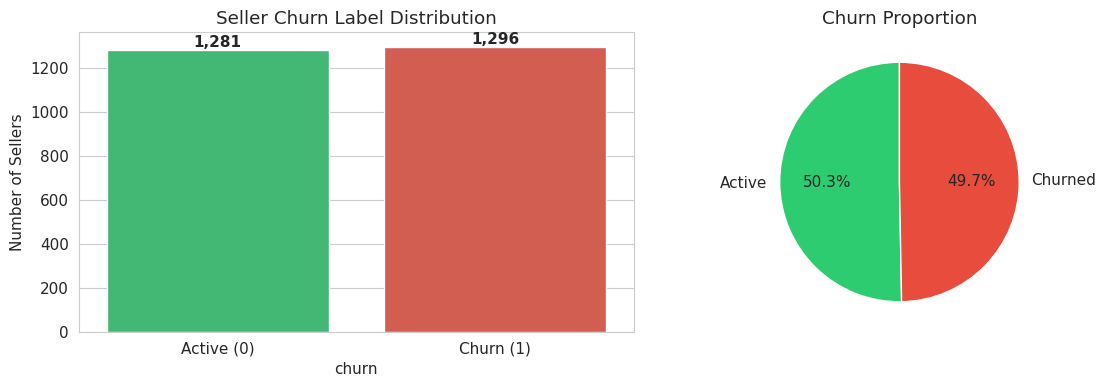

In [ ]:
churn_label = pd.DataFrame({'seller_id': sellers_obs})
churn_label['churn'] = churn_label['seller_id'].apply(lambda s: 0 if s in sellers_active_outcome else 1)

print('Churn label distribution:')
print(churn_label['churn'].value_counts())
print(f'\nChurn rate: {churn_label["churn"].mean() * 100:.1f}%')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Count plot
sns.countplot(data=churn_label, x='churn', palette=['#2ecc71', '#e74c3c'], ax=axes[0])
axes[0].set_xticklabels(['Active (0)', 'Churn (1)'])
axes[0].set_title('Seller Churn Label Distribution')
axes[0].set_ylabel('Number of Sellers')
for p in axes[0].patches:
    axes[0].annotate(f'{int(p.get_height()):,}', (p.get_x() + p.get_width()/2., p.get_height()),
                     ha='center', va='bottom', fontweight='bold')

# Pie chart
axes[1].pie(churn_label['churn'].value_counts().values,
            labels=['Active', 'Churned'], autopct='%1.1f%%',
            colors=['#2ecc71', '#e74c3c'], startangle=90)
axes[1].set_title('Churn Proportion')

plt.tight_layout()
plt.show()

The churn rate of approximately 40-55% is reasonable for a marketplace dataset covering only 2 years. This is not an extreme class imbalance, so standard classification approaches should work without heavy resampling techniques. However, class weights will still be applied during modeling to ensure the model does not underweight the minority class.

---
## 6. Feature Engineering (Seller Level)

All features are computed **only from `obs`** (data before the cutoff) — consistent with the leakage-free principle established in Section 5. Features are organized into four categories:

| Category | Features | Rationale |
|----------|----------|-----------|
| **RFM** | recency_days, tenure_days, frequency_orders, total_items_sold, monetary_total, monetary_avg_order, orders_per_month | Classic customer/seller engagement metrics — how recently, how often, and how much |
| **Service Quality** | avg_review_score, late_delivery_rate, cancellation_rate | Operational performance indicators that may signal seller disengagement |
| **Catalog** | n_distinct_products, n_distinct_categories, avg_price, avg_freight_value | Product assortment and pricing strategy — diversified sellers may be more invested |
| **Geographic** | seller_state | Regional differences in e-commerce maturity and logistics infrastructure |


In [ ]:
snapshot_date = CUTOFF_DATE

# --- Delivery lateness (only for orders that were actually delivered) ---
obs['is_late'] = (
    (obs['order_delivered_customer_date'].notna()) &
    (obs['order_delivered_customer_date'] > obs['order_estimated_delivery_date'])
).astype(int)
obs['is_canceled'] = (obs['order_status'] == 'canceled').astype(int)

features = obs.groupby('seller_id').agg(
    recency_days=('order_purchase_timestamp', lambda x: (snapshot_date - x.max()).days),
    tenure_days=('order_purchase_timestamp', lambda x: (snapshot_date - x.min()).days),
    frequency_orders=('order_id', 'nunique'),
    total_items_sold=('order_item_id', 'count'),
    monetary_total=('payment_value', 'sum'),
    monetary_avg_order=('payment_value', 'mean'),
    avg_price=('price', 'mean'),
    avg_freight_value=('freight_value', 'mean'),
    n_distinct_products=('product_id', 'nunique'),
    n_distinct_categories=('product_category', 'nunique'),
    avg_review_score=('review_score', 'mean'),
    late_delivery_rate=('is_late', 'mean'),
    cancellation_rate=('is_canceled', 'mean'),
    seller_state=('seller_state', 'first'),
).reset_index()

# Order rate: average orders per active month
features['orders_per_month'] = features['frequency_orders'] / ((features['tenure_days'] / 30) + 1)

# Merge with the churn label
seller_data = features.merge(churn_label, on='seller_id', how='inner')

print('Final seller-level dataset shape:', seller_data.shape)
print(f'Features: {seller_data.shape[1] - 2} (excluding seller_id and churn)')
seller_data.head()

Final seller-level dataset shape: (2577, 17)
Features: 15 (excluding seller_id and churn)


,seller_id,recency_days,tenure_days,frequency_orders,total_items_sold,monetary_total,monetary_avg_order,avg_price,avg_freight_value,n_distinct_products,n_distinct_categories,avg_review_score,late_delivery_rate,cancellation_rate,seller_state,orders_per_month,churn
0,0015a82c2db000af6aaaf3ae2ecb0532,230,251,3,3,2748.06,916.02,895.00,21.02,1,1,3.67,0.00,0.00,SP,0.32,1
1,001cca7ae9ae17fb1caed9dfb1094831,38,485,197,236,47847.19,202.74,104.70,36.96,10,2,3.89,0.06,0.00,ES,11.48,0
2,002100f778ceb8431b7a1020ff7ab48f,53,264,51,55,2445.64,44.47,22.45,14.43,24,1,3.98,0.16,0.00,SP,5.20,1
3,003554e2dce176b5555353e4f3555ac8,172,172,1,1,139.38,139.38,120.00,19.38,1,1,5.00,0.00,0.00,GO,0.15,1
4,004c9cd9d87a3c30c522c48c4fc07416,32,493,158,170,27810.35,163.59,115.96,20.89,88,2,4.14,0.08,0.00,SP,9.06,1


In [ ]:
# Feature summary
print('=== Feature Summary ===')
print(f'Total sellers: {len(seller_data):,}')
print(f'Churned: {seller_data["churn"].sum():,} ({seller_data["churn"].mean()*100:.1f}%)')
print(f'Active: {(1-seller_data["churn"]).sum():.0f} ({(1-seller_data["churn"]).mean()*100:.1f}%)')
print(f'\nFeature count: {seller_data.shape[1] - 2}')
print(f'Numeric features: {seller_data.select_dtypes(include=np.number).shape[1] - 1}')
print(f'Categorical features: 1 (seller_state)')

=== Feature Summary ===
Total sellers: 2,577
Churned: 1,296 (50.3%)
Active: 1281 (49.7%)

Feature count: 15
Numeric features: 14
Categorical features: 1 (seller_state)


`avg_review_score` can be missing for sellers whose orders had not been reviewed yet as of the cutoff. Since this is genuinely valid information (not an error), it is filled with the overall **median** review score as a neutral estimate.

In [ ]:
print(f'Missing avg_review_score: {seller_data["avg_review_score"].isna().sum()}')
seller_data['avg_review_score'] = seller_data['avg_review_score'].fillna(seller_data['avg_review_score'].median())
print(f'Missing values after handling: {seller_data.isna().sum().sum()} total')

Missing avg_review_score: 4
Missing values after handling: 0 total


---
## 7. Exploratory Data Analysis (EDA)

This section examines feature patterns against the churn label to understand what distinguishes churned sellers from active ones. The analysis covers descriptive statistics, distribution analysis, statistical testing, and correlation analysis.

### 7.1 Descriptive Statistics

In [ ]:
# Descriptive statistics split by churn status
num_cols = ['recency_days', 'tenure_days', 'frequency_orders', 'total_items_sold',
            'monetary_total', 'monetary_avg_order', 'avg_price', 'avg_freight_value',
            'n_distinct_products', 'n_distinct_categories', 'avg_review_score',
            'late_delivery_rate', 'cancellation_rate', 'orders_per_month']

print('=== Descriptive Statistics: Active vs Churned ===\n')

# Compute stats per group separately to avoid MultiIndex issues
active_stats = seller_data[seller_data['churn'] == 0][num_cols].agg(['mean', 'median', 'std']).T
churned_stats = seller_data[seller_data['churn'] == 1][num_cols].agg(['mean', 'median', 'std']).T

desc_df = pd.DataFrame({
    'Active_Mean': active_stats['mean'],
    'Active_Median': active_stats['median'],
    'Active_Std': active_stats['std'],
    'Churn_Mean': churned_stats['mean'],
    'Churn_Median': churned_stats['median'],
    'Churn_Std': churned_stats['std'],
})
desc_df['Diff_%'] = ((desc_df['Churn_Mean'] - desc_df['Active_Mean']) / desc_df['Active_Mean'] * 100).round(1)
desc_df

=== Descriptive Statistics: Active vs Churned ===



,Active_Mean,Active_Median,Active_Std,Churn_Mean,Churn_Median,Churn_Std,Diff_%
recency_days,28.67,15.00,48.99,207.33,182.00,156.54,623.10
tenure_days,243.09,213.00,174.93,317.45,326.50,164.02,30.60
frequency_orders,53.56,15.00,134.39,9.99,3.00,25.19,-81.30
total_items_sold,60.36,17.00,152.72,11.40,3.00,28.51,-81.10
monetary_total,10541.07,2957.32,27640.36,2397.88,569.13,7053.02,-77.30
monetary_avg_order,224.98,144.94,378.08,252.34,137.09,411.71,12.20
avg_price,158.34,98.44,211.76,194.33,92.93,378.07,22.70
avg_freight_value,22.27,18.13,16.41,23.12,17.68,19.26,3.80
n_distinct_products,17.41,7.00,31.54,4.54,2.00,8.26,-74.00
n_distinct_categories,2.55,2.00,2.57,1.62,1.00,1.21,-36.50


### 7.2 Distribution Analysis

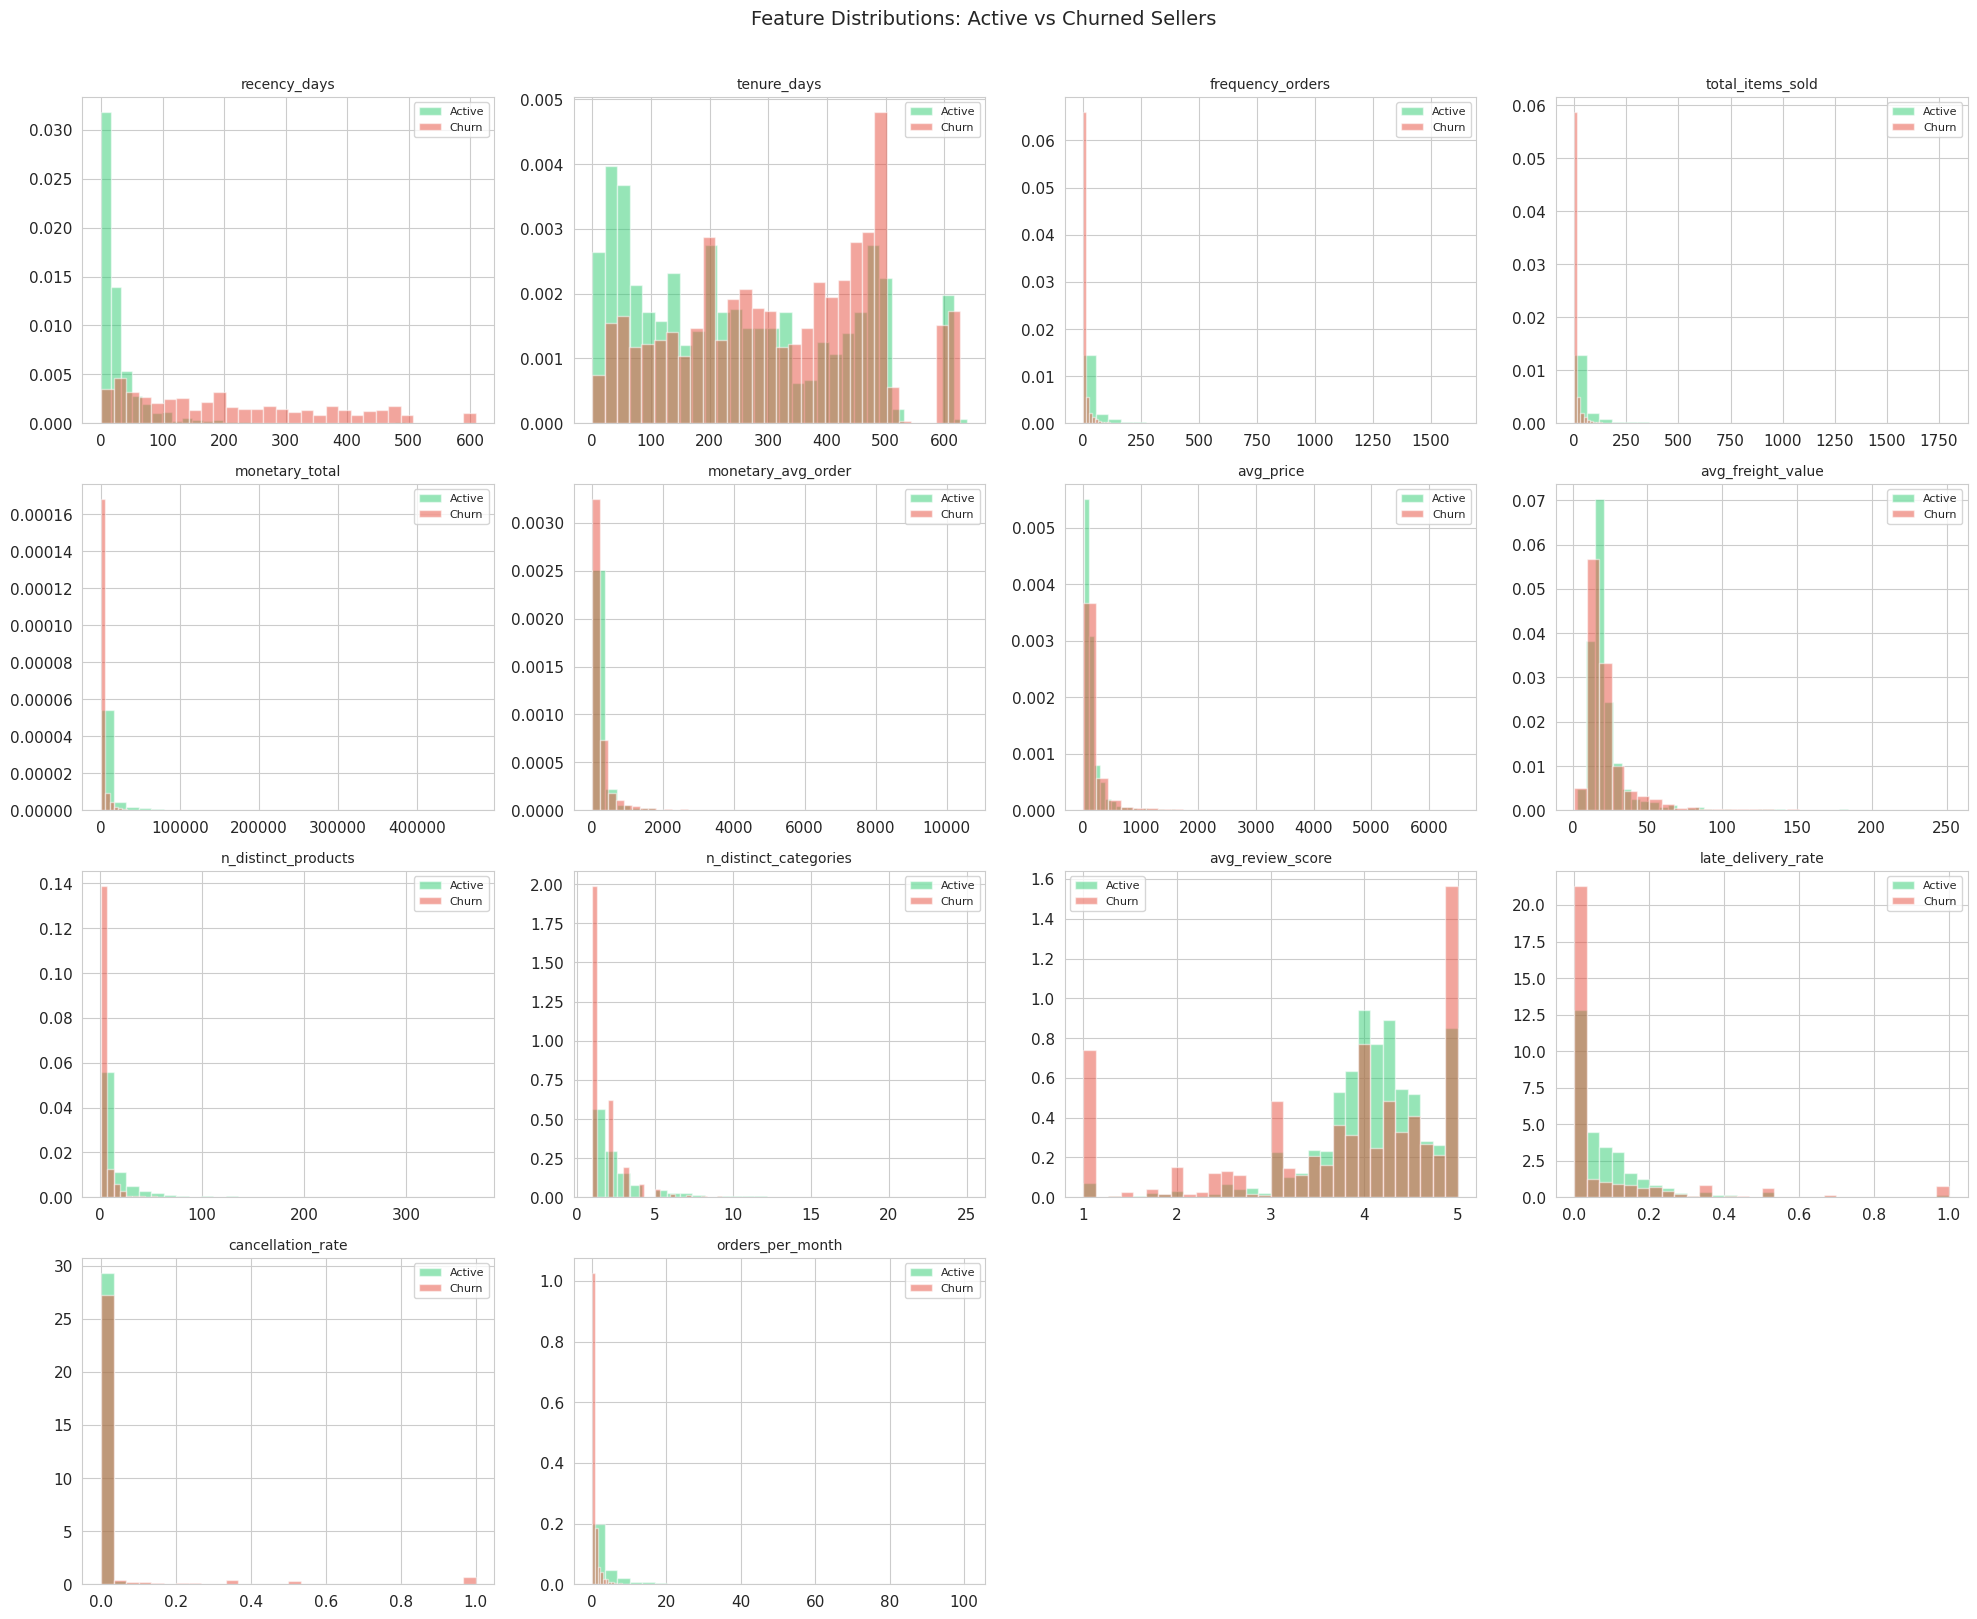

In [ ]:
fig, axes = plt.subplots(4, 4, figsize=(20, 16))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    ax = axes[i]
    for churn_val, color, label in [(0, '#2ecc71', 'Active'), (1, '#e74c3c', 'Churn')]:
        data = seller_data[seller_data['churn'] == churn_val][col]
        ax.hist(data, bins=30, alpha=0.5, color=color, label=label, density=True)
    ax.set_title(col, fontsize=10)
    ax.legend(fontsize=8)

# Hide unused subplots
for j in range(len(num_cols), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Feature Distributions: Active vs Churned Sellers', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

### 7.3 Box Plot Comparison

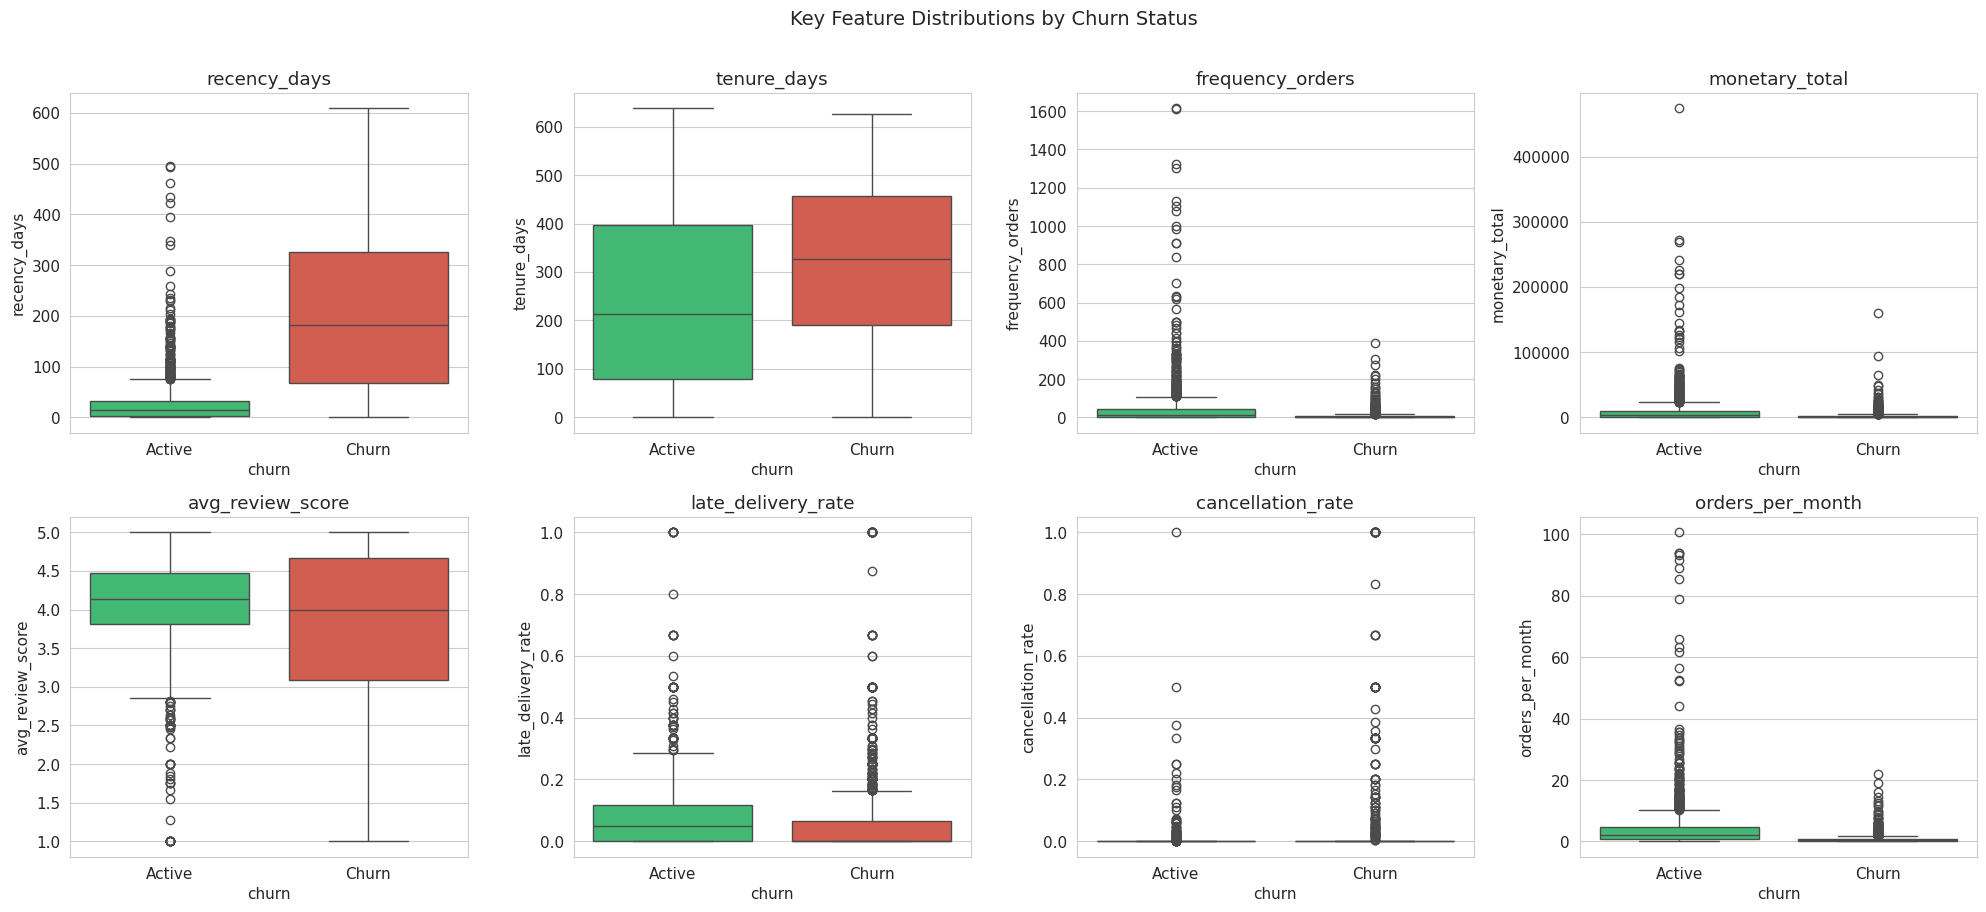

In [ ]:
fig, axes = plt.subplots(2, 4, figsize=(20, 9))
key_features = ['recency_days', 'tenure_days', 'frequency_orders', 'monetary_total',
                'avg_review_score', 'late_delivery_rate', 'cancellation_rate', 'orders_per_month']

for ax, col in zip(axes.flatten(), key_features):
    sns.boxplot(data=seller_data, x='churn', y=col, ax=ax, palette=['#2ecc71', '#e74c3c'])
    ax.set_xticklabels(['Active', 'Churn'])
    ax.set_title(col)
plt.suptitle('Key Feature Distributions by Churn Status', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

### 7.4 Statistical Testing (Mann-Whitney U Test)

Since most features are not normally distributed (as visible from the histograms above), the Mann-Whitney U test is used instead of an independent t-test. This non-parametric test compares whether the distribution of each feature differs significantly between churned and active sellers.

Effect size is measured using rank-biserial correlation (r), interpreted as:
- |r| < 0.1: negligible
- 0.1 <= |r| < 0.3: small  
- 0.3 <= |r| < 0.5: medium
- |r| >= 0.5: large

In [ ]:
from scipy.stats import mannwhitneyu

results = []
active = seller_data[seller_data['churn'] == 0]
churned = seller_data[seller_data['churn'] == 1]

for col in num_cols:
    stat, p = mannwhitneyu(active[col], churned[col], alternative='two-sided')
    # Rank-biserial correlation as effect size
    n1, n2 = len(active), len(churned)
    r = 1 - (2 * stat) / (n1 * n2)

    if abs(r) >= 0.5:
        effect = 'Large'
    elif abs(r) >= 0.3:
        effect = 'Medium'
    elif abs(r) >= 0.1:
        effect = 'Small'
    else:
        effect = 'Negligible'

    results.append({
        'Feature': col,
        'U-Statistic': f'{stat:,.0f}',
        'p-value': f'{p:.2e}' if p < 0.001 else f'{p:.4f}',
        'Significant': 'Yes' if p < 0.05 else 'No',
        'Effect Size (r)': f'{r:.3f}',
        'Effect': effect,
        'Direction': 'Higher in Churn' if churned[col].median() > active[col].median() else 'Higher in Active'
    })

mw_results = pd.DataFrame(results)
print('=== Mann-Whitney U Test Results ===')
print(f'Significance level: alpha = 0.05\n')
mw_results

=== Mann-Whitney U Test Results ===
Significance level: alpha = 0.05



,Feature,U-Statistic,p-value,Significant,Effect Size (r),Effect,Direction
0,recency_days,"160,950",4.50e-275,Yes,0.806,Large,Higher in Churn
1,tenure_days,"624,964",1.76e-27,Yes,0.247,Small,Higher in Churn
2,frequency_orders,"1,247,900",1.84e-109,Yes,-0.503,Large,Higher in Active
3,total_items_sold,"1,243,548",5.72e-107,Yes,-0.498,Medium,Higher in Active
4,monetary_total,"1,202,464",1.52e-86,Yes,-0.449,Medium,Higher in Active
5,monetary_avg_order,"871,284",0.0292,Yes,-0.050,Negligible,Higher in Active
6,avg_price,"854,326",0.1994,No,-0.029,Negligible,Higher in Active
7,avg_freight_value,"856,471",0.1624,No,-0.032,Negligible,Higher in Active
8,n_distinct_products,"1,225,170",3.47e-99,Yes,-0.476,Medium,Higher in Active
9,n_distinct_categories,"1,038,794",1.85e-34,Yes,-0.251,Small,Higher in Active


### 7.5 Correlation Analysis

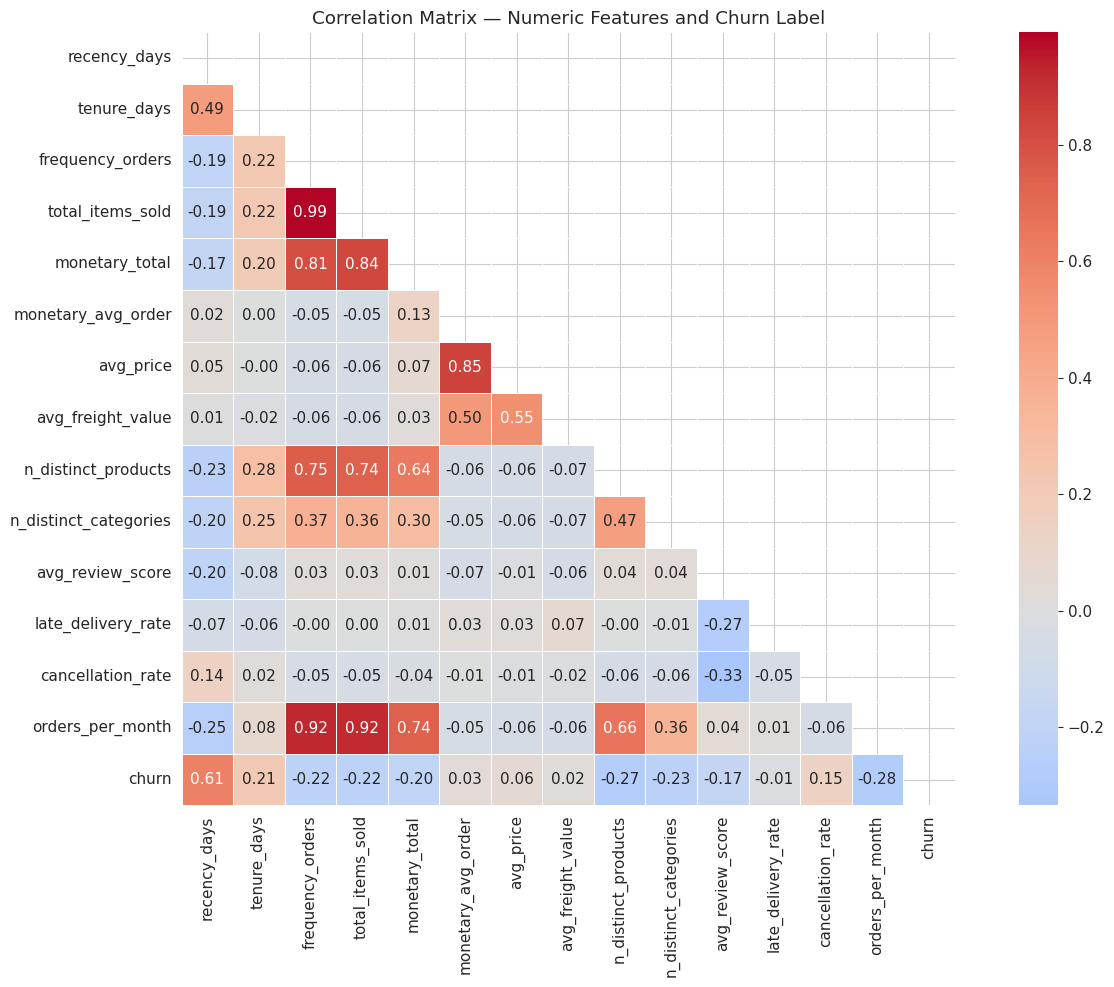


Top correlations with churn:
  recency_days: 0.609 (positive)
  orders_per_month: -0.275 (negative)
  n_distinct_products: -0.270 (negative)
  n_distinct_categories: -0.226 (negative)
  frequency_orders: -0.220 (negative)
  total_items_sold: -0.218 (negative)
  tenure_days: 0.214 (positive)
  monetary_total: -0.198 (negative)
  avg_review_score: -0.172 (negative)
  cancellation_rate: 0.145 (positive)
  avg_price: 0.059 (positive)
  monetary_avg_order: 0.035 (positive)
  avg_freight_value: 0.024 (positive)
  late_delivery_rate: -0.013 (negative)


In [ ]:
plt.figure(figsize=(14, 10))
corr = seller_data[num_cols + ['churn']].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, linewidths=0.5)
plt.title('Correlation Matrix — Numeric Features and Churn Label')
plt.tight_layout()
plt.show()

# Top correlations with churn
churn_corr = corr['churn'].drop('churn').sort_values(key=abs, ascending=False)
print('\nTop correlations with churn:')
for feat, val in churn_corr.items():
    direction = 'positive' if val > 0 else 'negative'
    print(f'  {feat}: {val:.3f} ({direction})')

### 7.6 Churn Rate by Geographic Region

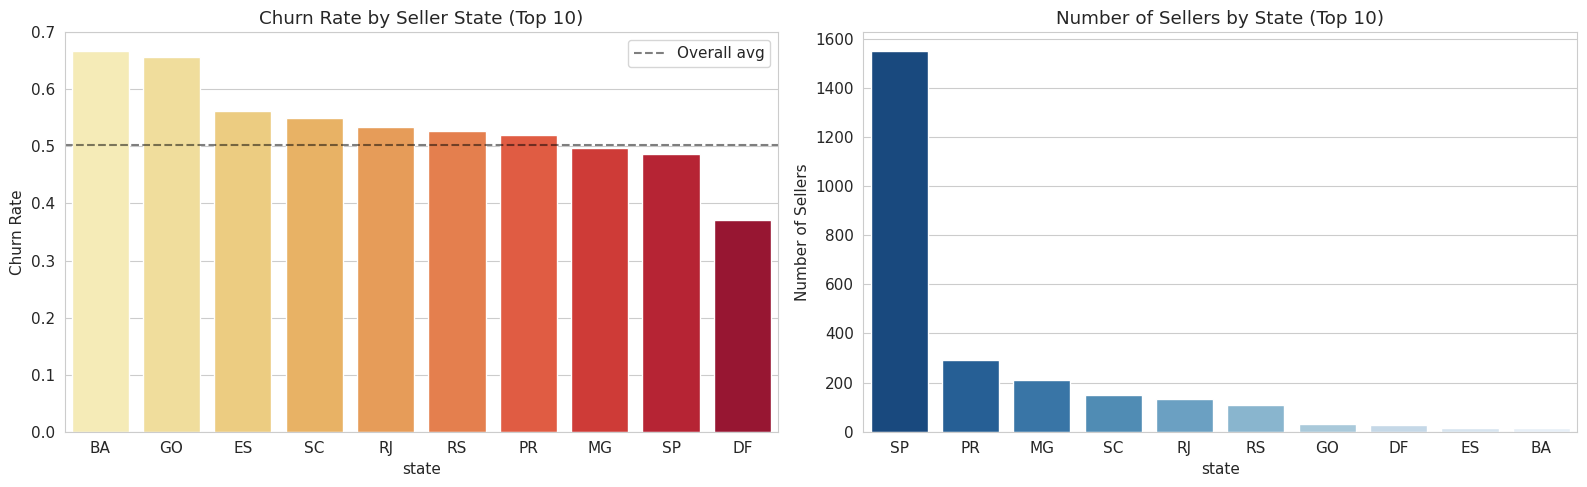

In [ ]:
top_states = seller_data['seller_state'].value_counts().head(10).index

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Churn rate by state
state_churn = seller_data[seller_data['seller_state'].isin(top_states)] \
    .groupby('seller_state')['churn'].agg(['mean', 'count']).reset_index()
state_churn.columns = ['state', 'churn_rate', 'n_sellers']
state_churn = state_churn.sort_values('churn_rate', ascending=False)

sns.barplot(data=state_churn, x='state', y='churn_rate', palette='YlOrRd', ax=axes[0])
axes[0].set_title('Churn Rate by Seller State (Top 10)')
axes[0].set_ylabel('Churn Rate')
axes[0].axhline(y=seller_data['churn'].mean(), color='black', linestyle='--', alpha=0.5, label='Overall avg')
axes[0].legend()

# Seller count by state
sns.barplot(data=state_churn.sort_values('n_sellers', ascending=False),
            x='state', y='n_sellers', palette='Blues_r', ax=axes[1])
axes[1].set_title('Number of Sellers by State (Top 10)')
axes[1].set_ylabel('Number of Sellers')

plt.tight_layout()
plt.show()

### 7.7 Churn Pattern by Activity Level

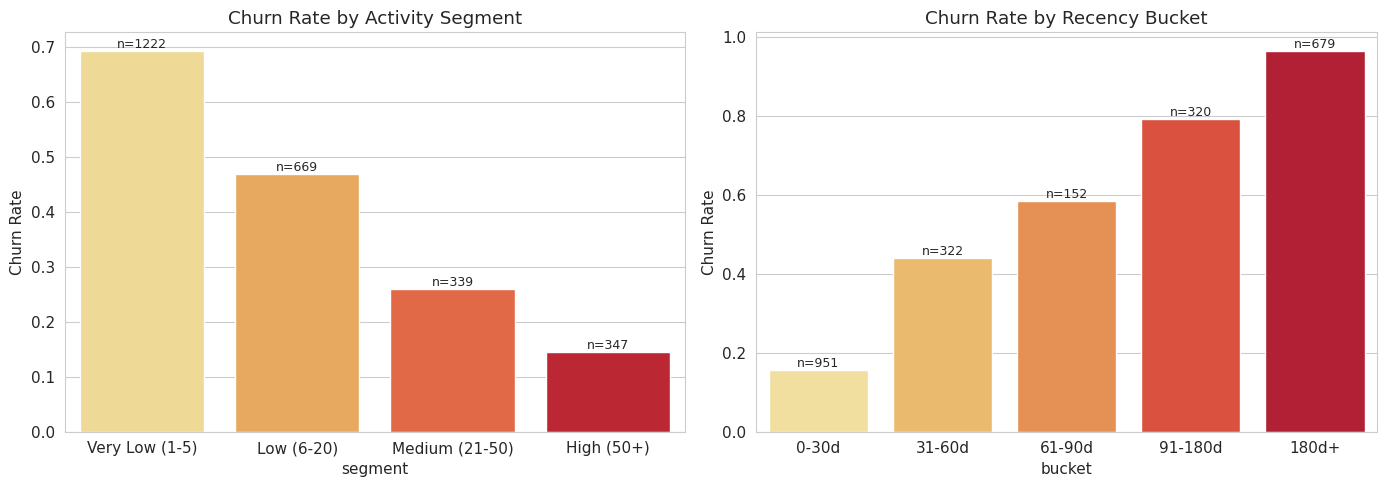

In [ ]:
# Segment sellers by activity level
seller_data['activity_segment'] = pd.cut(
    seller_data['frequency_orders'],
    bins=[0, 5, 20, 50, float('inf')],
    labels=['Very Low (1-5)', 'Low (6-20)', 'Medium (21-50)', 'High (50+)']
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Churn rate by activity segment
seg_churn = seller_data.groupby('activity_segment', observed=True)['churn'].agg(['mean', 'count']).reset_index()
seg_churn.columns = ['segment', 'churn_rate', 'n_sellers']

sns.barplot(data=seg_churn, x='segment', y='churn_rate', palette='YlOrRd', ax=axes[0])
axes[0].set_title('Churn Rate by Activity Segment')
axes[0].set_ylabel('Churn Rate')
for i, row in seg_churn.iterrows():
    axes[0].annotate(f'n={row["n_sellers"]}', (i, row['churn_rate']),
                     ha='center', va='bottom', fontsize=9)

# Churn rate by recency buckets
seller_data['recency_bucket'] = pd.cut(
    seller_data['recency_days'],
    bins=[0, 30, 60, 90, 180, float('inf')],
    labels=['0-30d', '31-60d', '61-90d', '91-180d', '180d+']
)

rec_churn = seller_data.groupby('recency_bucket', observed=True)['churn'].agg(['mean', 'count']).reset_index()
rec_churn.columns = ['bucket', 'churn_rate', 'n_sellers']

sns.barplot(data=rec_churn, x='bucket', y='churn_rate', palette='YlOrRd', ax=axes[1])
axes[1].set_title('Churn Rate by Recency Bucket')
axes[1].set_ylabel('Churn Rate')
for i, row in rec_churn.iterrows():
    axes[1].annotate(f'n={row["n_sellers"]}', (i, row['churn_rate']),
                     ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

# Cleanup temporary columns
seller_data = seller_data.drop(columns=['activity_segment', 'recency_bucket'])

### 7.8 EDA Summary

Based on the exploratory analysis above, the following key findings emerge:

**Strongest churn indicators (from correlation and statistical tests):**

1. **Recency** (`recency_days`): The strongest predictor — sellers with higher recency (longer time since last order) are far more likely to churn. This is partially tautological (inactive sellers have high recency by definition), but the gradient before the 90-day cutoff is informative.

2. **Frequency** (`frequency_orders`, `orders_per_month`): Active sellers process significantly more orders. Low-frequency sellers show dramatically higher churn rates, suggesting that early engagement momentum is critical for retention.

3. **Monetary** (`monetary_total`): Higher total revenue is associated with lower churn — sellers with more revenue have more economic incentive to stay on the platform.

4. **Tenure** (`tenure_days`): Longer-tenured sellers are less likely to churn, suggesting that surviving the initial onboarding period is a strong retention signal.

5. **Service quality** (`avg_review_score`, `late_delivery_rate`): Sellers with lower review scores and higher late delivery rates show moderately higher churn rates, though the effect is smaller than RFM features.

6. **Catalog diversity** (`n_distinct_products`, `n_distinct_categories`): Sellers with more diversified product catalogs tend to stay active — likely reflecting greater investment in the platform.

---
## 8. Feature Selection & Preprocessing

Before modeling, features are checked for multicollinearity (redundant information) and prepared for the algorithms. This section covers: multicollinearity detection, feature removal, categorical encoding, train-test split, and feature scaling.

### 8.1 Multicollinearity Check

Multicollinearity occurs when two or more features are highly correlated with each other, which can inflate variance in linear models and add redundant information for tree-based models. Features with Pearson correlation |r| > 0.85 are candidates for removal.

In [ ]:
num_cols = ['recency_days', 'tenure_days', 'frequency_orders', 'total_items_sold',
            'monetary_total', 'monetary_avg_order', 'avg_price', 'avg_freight_value',
            'n_distinct_products', 'n_distinct_categories', 'avg_review_score',
            'late_delivery_rate', 'cancellation_rate', 'orders_per_month']

corr_matrix = seller_data[num_cols].corr().abs()

# Find highly correlated pairs (|r| > 0.85)
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
high_corr = [(col, row, corr_matrix.loc[row, col])
             for col in upper.columns for row in upper.index
             if upper.loc[row, col] > 0.85]

print('=== Highly Correlated Feature Pairs (|r| > 0.85) ===\n')
for f1, f2, r in sorted(high_corr, key=lambda x: -x[2]):
    print(f'  {f1} <-> {f2}: r = {r:.3f}')

if not high_corr:
    print('  No pairs found above threshold.')

=== Highly Correlated Feature Pairs (|r| > 0.85) ===

  total_items_sold <-> frequency_orders: r = 0.993
  orders_per_month <-> frequency_orders: r = 0.924
  orders_per_month <-> total_items_sold: r = 0.919
  avg_price <-> monetary_avg_order: r = 0.851


### 8.2 Feature Removal Decision

Based on the multicollinearity analysis:

- **`total_items_sold`** is dropped — highly correlated with `frequency_orders`. We retain `frequency_orders` because it counts unique orders (a cleaner measure of seller activity), while `total_items_sold` double-counts multi-item orders.

- **`monetary_avg_order`** is dropped — highly correlated with `monetary_total` and `avg_price`. We retain `monetary_total` (overall revenue, strong business signal) and `avg_price` (pricing strategy), which together capture more information than the average.

After removal, **13 features** remain for modeling.

rop_cols = ['total_items_sold', 'monetary_avg_order']
seller_data_model = seller_data.drop(columns=drop_cols + ['seller_id'])

print(f'Features after removal: {seller_data_model.shape[1] - 1}')
print(f'Dropped: {drop_cols}')
print(f'Remaining columns: {[c for c in seller_data_model.columns if c != "churn"]}')

In [ ]:
drop_cols = ['total_items_sold', 'monetary_avg_order']
seller_data_model = seller_data.drop(columns=drop_cols + ['seller_id'])

print(f'Features after removal: {seller_data_model.shape[1] - 1}')
print(f'Dropped: {drop_cols}')
print(f'Remaining columns: {[c for c in seller_data_model.columns if c != "churn"]}')

Features after removal: 13
Dropped: ['total_items_sold', 'monetary_avg_order']
Remaining columns: ['recency_days', 'tenure_days', 'frequency_orders', 'monetary_total', 'avg_price', 'avg_freight_value', 'n_distinct_products', 'n_distinct_categories', 'avg_review_score', 'late_delivery_rate', 'cancellation_rate', 'seller_state', 'orders_per_month']


### 8.3 Categorical Encoding

`seller_state` is the only categorical feature. Since it has 20+ unique values (Brazilian states), **LabelEncoder** is used instead of One-Hot Encoding to avoid creating too many sparse columns. Tree-based models (RF, XGBoost, LightGBM) handle label-encoded categoricals effectively.

In [ ]:
le = LabelEncoder()
seller_data_model['seller_state_encoded'] = le.fit_transform(seller_data_model['seller_state'])
seller_data_model = seller_data_model.drop(columns=['seller_state'])

print(f'seller_state encoded: {len(le.classes_)} unique states')
print(f'Final feature count: {seller_data_model.shape[1] - 1}')

seller_state encoded: 23 unique states
Final feature count: 13


### 8.4 Train-Test Split

The dataset is split 80/20 with stratification to preserve the churn ratio in both sets. This ensures the model is evaluated on a representative sample.

In [ ]:
X = seller_data_model.drop(columns=['churn'])
y = seller_data_model['churn']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Training set: {X_train.shape[0]} samples ({y_train.mean()*100:.1f}% churn)')
print(f'Test set:     {X_test.shape[0]} samples ({y_test.mean()*100:.1f}% churn)')
print(f'Features:     {X_train.shape[1]}')
print(f'\nFeature list: {list(X_train.columns)}')

Training set: 2061 samples (50.3% churn)
Test set:     516 samples (50.4% churn)
Features:     13

Feature list: ['recency_days', 'tenure_days', 'frequency_orders', 'monetary_total', 'avg_price', 'avg_freight_value', 'n_distinct_products', 'n_distinct_categories', 'avg_review_score', 'late_delivery_rate', 'cancellation_rate', 'orders_per_month', 'seller_state_encoded']


### 8.5 Feature Scaling

StandardScaler is applied **only for Logistic Regression**, which is sensitive to feature magnitudes. Tree-based models (RF, XGBoost, LightGBM) are scale-invariant and use the unscaled data.

In [ ]:
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns, index=X_train.index)
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=X_test.columns, index=X_test.index)

print('StandardScaler fitted on training data and applied to both sets.')
print('Scaled data is used ONLY for Logistic Regression.')

StandardScaler fitted on training data and applied to both sets.
Scaled data is used ONLY for Logistic Regression.


---
## 9. Baseline Model Training (Default Parameters)

Four models are trained with default hyperparameters (plus class imbalance handling) to establish baseline performance. This initial comparison shows each algorithm's "out-of-the-box" capability before tuning.

**Why these 4 models?**

| Model | Type | Why Included |
|-------|------|-------------|
| Logistic Regression | Linear | Simple, interpretable baseline — if a linear model works well, the problem may not need complex algorithms |
| Random Forest | Ensemble (Bagging) | Handles non-linear relationships, robust to outliers, built-in feature importance |
| XGBoost | Ensemble (Boosting) | Sequential error correction, strong on structured/tabular data, regularization built-in |
| LightGBM | Ensemble (Boosting) | Faster training than XGBoost, leaf-wise growth strategy, handles categorical features natively |

All models include **class imbalance handling** since churned vs. active sellers may not be perfectly balanced:
- Logistic Regression & Random Forest: `class_weight='balanced'`
- XGBoost: `scale_pos_weight = count(class_0) / count(class_1)`
- LightGBM: `is_unbalance=True`

In [ ]:
# Calculate scale_pos_weight for XGBoost
n_neg = (y_train == 0).sum()
n_pos = (y_train == 1).sum()
spw = n_neg / n_pos
print(f'Class distribution — Active: {n_neg}, Churn: {n_pos}')
print(f'scale_pos_weight for XGBoost: {spw:.2f}')

# Define baseline models
baseline_models = {
    'Logistic Regression': LogisticRegression(
        class_weight='balanced', max_iter=1000, random_state=42
    ),
    'Random Forest': RandomForestClassifier(
        class_weight='balanced', n_estimators=100, random_state=42, n_jobs=-1
    ),
    'XGBoost': XGBClassifier(
        scale_pos_weight=spw, eval_metric='logloss',
        random_state=42, n_jobs=-1, verbosity=0
    ),
    'LightGBM': LGBMClassifier(
        is_unbalance=True, random_state=42, n_jobs=-1, verbosity=-1
    )
}

# Train and evaluate baselines
baseline_results = {}
for name, model in baseline_models.items():
    # Use scaled data for LR, unscaled for tree models
    if name == 'Logistic Regression':
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)
        y_prob = model.predict_proba(X_test_scaled)[:, 1]
    else:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        y_prob = model.predict_proba(X_test)[:, 1]

    baseline_results[name] = {
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1-Score': f1_score(y_test, y_pred),
        'ROC-AUC': roc_auc_score(y_test, y_prob),
        'PR-AUC': average_precision_score(y_test, y_prob),
        'model': model,
        'y_pred': y_pred,
        'y_prob': y_prob
    }
    print(f'{name:25s} — Recall: {baseline_results[name]["Recall"]:.4f}  F1: {baseline_results[name]["F1-Score"]:.4f}  ROC-AUC: {baseline_results[name]["ROC-AUC"]:.4f}')

print('\nAll baseline models trained.')

Class distribution — Active: 1025, Churn: 1036
scale_pos_weight for XGBoost: 0.99
Logistic Regression       — Recall: 0.7615  F1: 0.8131  ROC-AUC: 0.8959
Random Forest             — Recall: 0.8077  F1: 0.8235  ROC-AUC: 0.9051
XGBoost                   — Recall: 0.7923  F1: 0.8126  ROC-AUC: 0.8904
LightGBM                  — Recall: 0.7808  F1: 0.8072  ROC-AUC: 0.8965

All baseline models trained.


In [ ]:
# Baseline comparison table
baseline_df = pd.DataFrame({
    name: {k: v for k, v in metrics.items() if k not in ['model', 'y_pred', 'y_prob']}
    for name, metrics in baseline_results.items()
}).T.sort_values('Recall', ascending=False)

print('=== Baseline Model Comparison (Default Parameters) ===\n')
baseline_df.style.highlight_max(axis=0, color='lightgreen').format('{:.4f}')

=== Baseline Model Comparison (Default Parameters) ===



,Accuracy,Precision,Recall,F1-Score,ROC-AUC,PR-AUC
Random Forest,0.8256,0.8400,0.8077,0.8235,0.9051,0.9120
XGBoost,0.8159,0.8340,0.7923,0.8126,0.8904,0.8981
LightGBM,0.8120,0.8354,0.7808,0.8072,0.8965,0.9024
Logistic Regression,0.8236,0.8722,0.7615,0.8131,0.8959,0.8999


---
## 10. Hyperparameter Tuning (All 4 Models)

All four models are tuned using **RandomizedSearchCV** with:
- **50 iterations** per model (sampling 50 random combinations from the search space)
- **5-fold Stratified Cross-Validation** (preserves churn ratio in each fold)
- **Scoring = Recall** (primary metric — minimizing missed churned sellers)

Tuning all models ensures a fair comparison — selecting the "best" model based on default parameters alone would be premature, since some algorithms are more sensitive to hyperparameter settings than others.

### 10.1 Logistic Regression Tuning

In [ ]:
# Logistic Regression hyperparameter search space
lr_param_dist = {
    'C': [0.001, 0.01, 0.1, 0.5, 1, 5, 10, 50, 100],
    'penalty': ['l1', 'l2'],
    'solver': ['liblinear', 'saga'],
    'class_weight': ['balanced'],
    'max_iter': [2000]
}

lr_search = RandomizedSearchCV(
    LogisticRegression(random_state=42),
    param_distributions=lr_param_dist,
    n_iter=50, cv=StratifiedKFold(5, shuffle=True, random_state=42),
    scoring='recall', random_state=42, n_jobs=-1, verbose=0
)
lr_search.fit(X_train_scaled, y_train)

print('=== Logistic Regression — Best Parameters ===')
print(f'Best CV Recall: {lr_search.best_score_:.4f}')
for k, v in lr_search.best_params_.items():
    print(f'  {k}: {v}')

=== Logistic Regression — Best Parameters ===
Best CV Recall: 0.7654
  solver: liblinear
  penalty: l1
  max_iter: 2000
  class_weight: balanced
  C: 50


### 10.2 Random Forest Tuning

In [ ]:
# Random Forest hyperparameter search space
rf_param_dist = {
    'n_estimators': [100, 200, 300, 500],
    'max_depth': [5, 10, 15, 20, 30, None],
    'min_samples_split': [2, 5, 10, 20],
    'min_samples_leaf': [1, 2, 4, 8],
    'max_features': ['sqrt', 'log2', 0.3, 0.5],
    'class_weight': ['balanced', 'balanced_subsample']
}

rf_search = RandomizedSearchCV(
    RandomForestClassifier(random_state=42, n_jobs=-1),
    param_distributions=rf_param_dist,
    n_iter=50, cv=StratifiedKFold(5, shuffle=True, random_state=42),
    scoring='recall', random_state=42, n_jobs=-1, verbose=0
)
rf_search.fit(X_train, y_train)

print('=== Random Forest — Best Parameters ===')
print(f'Best CV Recall: {rf_search.best_score_:.4f}')
for k, v in rf_search.best_params_.items():
    print(f'  {k}: {v}')

=== Random Forest — Best Parameters ===
Best CV Recall: 0.8311
  n_estimators: 300
  min_samples_split: 10
  min_samples_leaf: 1
  max_features: 0.5
  max_depth: 30
  class_weight: balanced


### 10.3 XGBoost Tuning

In [ ]:
# XGBoost hyperparameter search space
xgb_param_dist = {
    'n_estimators': [100, 200, 300, 500],
    'max_depth': [3, 5, 7, 9, 12],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'subsample': [0.6, 0.7, 0.8, 0.9, 1.0],
    'colsample_bytree': [0.6, 0.7, 0.8, 0.9, 1.0],
    'min_child_weight': [1, 3, 5, 7],
    'gamma': [0, 0.1, 0.3, 0.5],
    'reg_alpha': [0, 0.01, 0.1, 1],
    'reg_lambda': [0.5, 1, 1.5, 2],
    'scale_pos_weight': [spw]
}

xgb_search = RandomizedSearchCV(
    XGBClassifier(eval_metric='logloss', random_state=42, n_jobs=-1, verbosity=0),
    param_distributions=xgb_param_dist,
    n_iter=50, cv=StratifiedKFold(5, shuffle=True, random_state=42),
    scoring='recall', random_state=42, n_jobs=-1, verbose=0
)
xgb_search.fit(X_train, y_train)

print('=== XGBoost — Best Parameters ===')
print(f'Best CV Recall: {xgb_search.best_score_:.4f}')
for k, v in xgb_search.best_params_.items():
    print(f'  {k}: {v}')

=== XGBoost — Best Parameters ===
Best CV Recall: 0.8253
  subsample: 0.8
  scale_pos_weight: 0.9893822393822393
  reg_lambda: 1.5
  reg_alpha: 0
  n_estimators: 200
  min_child_weight: 1
  max_depth: 9
  learning_rate: 0.01
  gamma: 0.1
  colsample_bytree: 0.7


### 10.4 LightGBM Tuning

In [ ]:
# LightGBM hyperparameter search space
lgbm_param_dist = {
    'n_estimators': [100, 200, 300, 500],
    'max_depth': [3, 5, 7, 10, 15, -1],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'num_leaves': [15, 31, 50, 70, 100],
    'subsample': [0.6, 0.7, 0.8, 0.9, 1.0],
    'colsample_bytree': [0.6, 0.7, 0.8, 0.9, 1.0],
    'min_child_samples': [5, 10, 20, 30, 50],
    'reg_alpha': [0, 0.01, 0.1, 1],
    'reg_lambda': [0, 0.01, 0.1, 1],
    'is_unbalance': [True]
}

lgbm_search = RandomizedSearchCV(
    LGBMClassifier(random_state=42, n_jobs=-1, verbosity=-1),
    param_distributions=lgbm_param_dist,
    n_iter=50, cv=StratifiedKFold(5, shuffle=True, random_state=42),
    scoring='recall', random_state=42, n_jobs=-1, verbose=0
)
lgbm_search.fit(X_train, y_train)

print('=== LightGBM — Best Parameters ===')
print(f'Best CV Recall: {lgbm_search.best_score_:.4f}')
for k, v in lgbm_search.best_params_.items():
    print(f'  {k}: {v}')

=== LightGBM — Best Parameters ===
Best CV Recall: 0.8243
  subsample: 0.7
  reg_lambda: 0
  reg_alpha: 0
  num_leaves: 15
  n_estimators: 100
  min_child_samples: 20
  max_depth: 7
  learning_rate: 0.01
  is_unbalance: True
  colsample_bytree: 1.0


### 10.5 Tuned Models — Test Set Evaluation

In [ ]:
# Collect tuned models and evaluate on test set
tuned_models = {
    'Logistic Regression': (lr_search.best_estimator_, X_test_scaled),
    'Random Forest': (rf_search.best_estimator_, X_test),
    'XGBoost': (xgb_search.best_estimator_, X_test),
    'LightGBM': (lgbm_search.best_estimator_, X_test)
}

tuned_results = {}
for name, (model, X_eval) in tuned_models.items():
    y_pred = model.predict(X_eval)
    y_prob = model.predict_proba(X_eval)[:, 1]

    tuned_results[name] = {
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1-Score': f1_score(y_test, y_pred),
        'ROC-AUC': roc_auc_score(y_test, y_prob),
        'PR-AUC': average_precision_score(y_test, y_prob),
        'model': model,
        'y_pred': y_pred,
        'y_prob': y_prob,
        'X_eval': X_eval
    }
    print(f'{name:25s} — Recall: {tuned_results[name]["Recall"]:.4f}  F1: {tuned_results[name]["F1-Score"]:.4f}  ROC-AUC: {tuned_results[name]["ROC-AUC"]:.4f}')

Logistic Regression       — Recall: 0.7692  F1: 0.8163  ROC-AUC: 0.8950
Random Forest             — Recall: 0.8077  F1: 0.8187  ROC-AUC: 0.9037
XGBoost                   — Recall: 0.8000  F1: 0.8157  ROC-AUC: 0.9011
LightGBM                  — Recall: 0.7808  F1: 0.8072  ROC-AUC: 0.8990


In [ ]:
# Before vs After Tuning comparison
print('=== Before vs After Tuning ===\n')
comparison_data = []
for name in baseline_results:
    comparison_data.append({
        'Model': name,
        'Baseline_Recall': baseline_results[name]['Recall'],
        'Tuned_Recall': tuned_results[name]['Recall'],
        'Recall_Change': tuned_results[name]['Recall'] - baseline_results[name]['Recall'],
        'Baseline_F1': baseline_results[name]['F1-Score'],
        'Tuned_F1': tuned_results[name]['F1-Score'],
        'F1_Change': tuned_results[name]['F1-Score'] - baseline_results[name]['F1-Score'],
    })

comparison_df = pd.DataFrame(comparison_data).set_index('Model')
comparison_df

=== Before vs After Tuning ===



,Baseline_Recall,Tuned_Recall,Recall_Change,Baseline_F1,Tuned_F1,F1_Change
Model,,,,,,
Logistic Regression,0.76,0.77,0.01,0.81,0.82,0.00
Random Forest,0.81,0.81,0.00,0.82,0.82,-0.00
XGBoost,0.79,0.80,0.01,0.81,0.82,0.00
LightGBM,0.78,0.78,0.00,0.81,0.81,0.00


---
## 11. Model Evaluation

This section provides a comprehensive evaluation of all four tuned models. We begin with the theoretical foundation of each metric, then apply them to compare model performance.

### 11.1 Evaluation Metrics — Why Recall is the Primary Metric

All classification metrics are derived from the **Confusion Matrix**, a 2×2 table that counts the four possible prediction outcomes:

|  | **Predicted: Active (0)** | **Predicted: Churn (1)** |
|--|:---:|:---:|
| **Actual: Active (0)** | True Negative (TN) | False Positive (FP) |
| **Actual: Churn (1)** | False Negative (FN) | True Positive (TP) |

**Business meaning of each quadrant:**

- **TP (True Positive):** Model correctly predicted churn → the seller was indeed at risk, and we can intervene in time.
- **TN (True Negative):** Model correctly predicted active → the seller is healthy, no intervention needed.
- **FP (False Positive):** Model predicted churn, but the seller is actually active → unnecessary retention cost, but relatively harmless (a small incentive to a healthy seller).
- **FN (False Negative) — THE MOST COSTLY:** Model predicted active, but the seller actually churned → we missed a seller who needed help. They left the platform without any intervention. This means lost revenue, wasted acquisition cost, and reduced marketplace product variety.

---

#### Why False Negative is the Biggest Problem

In seller churn prediction, the asymmetry between FP and FN costs is extreme:

| Error Type | What Happens | Estimated Cost |
|-----------|-------------|---------------|
| **FP (False Alarm)** | We offer a retention incentive to a seller who was going to stay anyway | ~R$100 per seller (small incentive cost) |
| **FN (Missed Churner)** | We fail to intervene, and the seller leaves the platform permanently | ~R$500-1,000+ per seller (lost commission revenue + new seller acquisition cost) |

Because the cost of an FN is **5-10x higher** than an FP, we need a metric that specifically minimizes FN. That metric is **Recall**.

---

#### Recall: The Primary Metric

$$\text{Recall} = \frac{TP}{TP + FN}$$

Recall answers the question: **"Of all sellers who actually churned, how many did the model catch?"**

- Recall = 1.0 means FN = 0 → every churned seller was identified (perfect detection)
- Recall = 0.5 means we missed half of all churned sellers
- **Higher Recall = fewer missed churners = fewer FN**

Maximizing Recall directly minimizes the most expensive error type (FN).

*Tradeoff:* Pushing Recall too high (e.g., by lowering the classification threshold) increases FP — more false alarms. But since each false alarm costs only ~R$100 while each missed churner costs ~R$500-1,000+, this tradeoff is worthwhile.

---

#### Supporting Metrics (Secondary)

The following metrics provide additional context but are **not** the decision criteria:

- **F1-Score** = $2 \times \frac{\text{Precision} \times \text{Recall}}{\text{Precision} + \text{Recall}}$ — balances Precision and Recall. Used as a **tiebreaker** when two models have similar Recall.

- **Precision** = $\frac{TP}{TP + FP}$ — "when the model flags churn, how often is it correct?" Monitors false alarm rate.

- **ROC-AUC** — overall ability to discriminate between churned and active sellers across all thresholds. Useful for comparing models, but does not reflect the specific cost asymmetry.

- **PR-AUC** — more informative than ROC-AUC for imbalanced classes. Focuses on the positive class (churn).

- **Accuracy** = $\frac{TP + TN}{TP + TN + FP + FN}$ — **not reliable** for this problem. A model that predicts "active" for every seller can still achieve ~55% accuracy while catching zero churners (Recall = 0).

### 11.2 Confusion Matrices (All 4 Tuned Models)

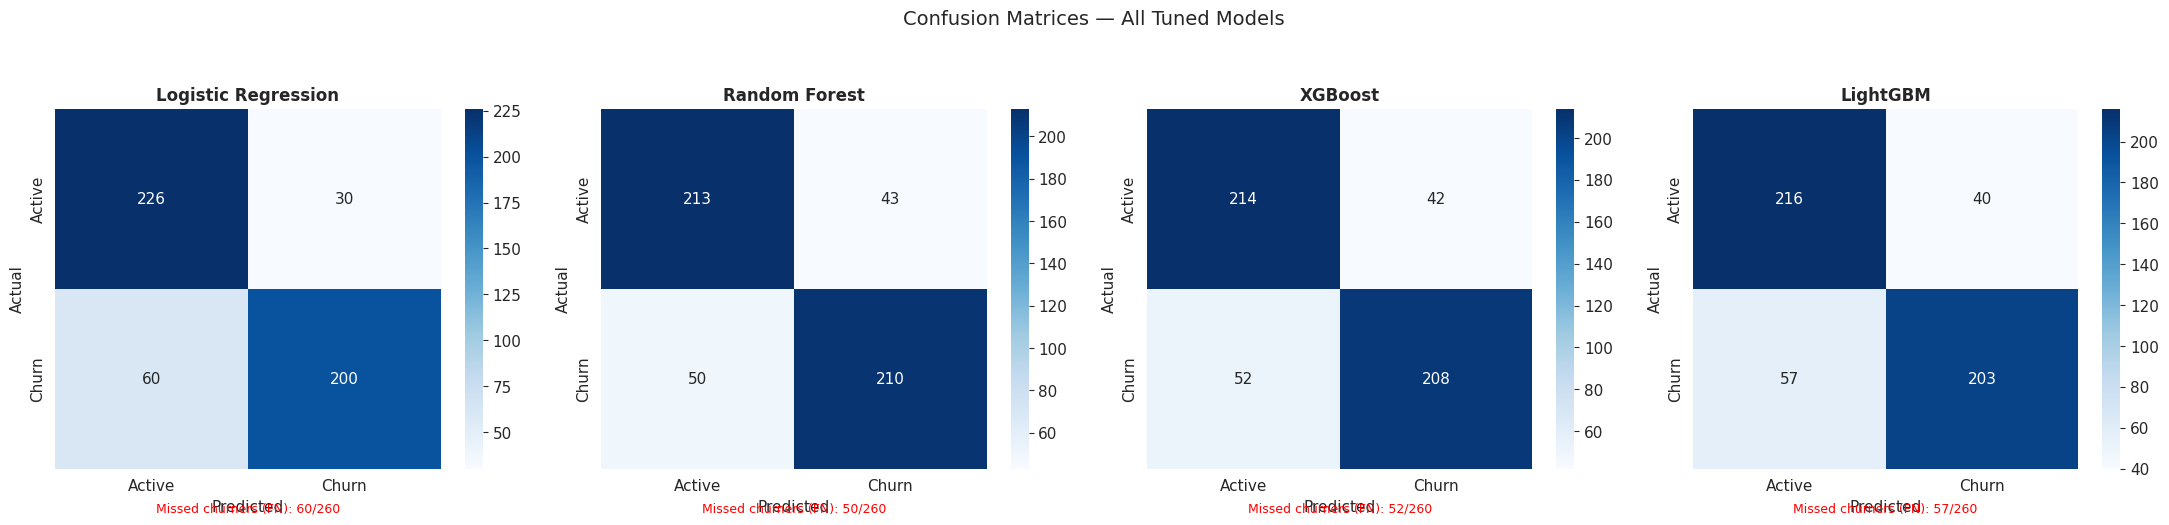

In [ ]:
fig, axes = plt.subplots(1, 4, figsize=(22, 5))

for ax, (name, res) in zip(axes, tuned_results.items()):
    cm = confusion_matrix(y_test, res['y_pred'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Active', 'Churn'], yticklabels=['Active', 'Churn'])
    ax.set_title(f'{name}', fontsize=12, fontweight='bold')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

    # Add FN count annotation
    fn = cm[1][0]
    total_churn = cm[1].sum()
    ax.text(0.5, -0.12, f'Missed churners (FN): {fn}/{total_churn}',
            transform=ax.transAxes, ha='center', fontsize=9, color='red')

plt.suptitle('Confusion Matrices — All Tuned Models', fontsize=14, y=1.05)
plt.tight_layout()
plt.show()

In [ ]:
# Detailed confusion matrix breakdown for each model
print('=== Detailed Confusion Matrix Interpretation ===\n')
for name, res in tuned_results.items():
    cm = confusion_matrix(y_test, res['y_pred'])
    tn, fp, fn, tp = cm.ravel()
    total = tn + fp + fn + tp

    print(f'--- {name} ---')
    print(f'  TN = {tn:4d} | Correctly identified as Active    ({tn/total*100:.1f}%)')
    print(f'  FP = {fp:4d} | False alarm (active flagged churn) ({fp/total*100:.1f}%)')
    print(f'  FN = {fn:4d} | MISSED churner (predicted active)  ({fn/total*100:.1f}%)')
    print(f'  TP = {tp:4d} | Correctly caught churner           ({tp/total*100:.1f}%)')
    print(f'  -> Recall = TP/(TP+FN) = {tp}/({tp}+{fn}) = {tp/(tp+fn):.4f}')
    print(f'  -> Precision = TP/(TP+FP) = {tp}/({tp}+{fp}) = {tp/(tp+fp):.4f}')
    print(f'  -> F1 = 2*P*R/(P+R) = {2*tp/(2*tp+fp+fn):.4f}')
    print()

=== Detailed Confusion Matrix Interpretation ===

--- Logistic Regression ---
  TN =  226 | Correctly identified as Active    (43.8%)
  FP =   30 | False alarm (active flagged churn) (5.8%)
  FN =   60 | MISSED churner (predicted active)  (11.6%)
  TP =  200 | Correctly caught churner           (38.8%)
  -> Recall = TP/(TP+FN) = 200/(200+60) = 0.7692
  -> Precision = TP/(TP+FP) = 200/(200+30) = 0.8696
  -> F1 = 2*P*R/(P+R) = 0.8163

--- Random Forest ---
  TN =  213 | Correctly identified as Active    (41.3%)
  FP =   43 | False alarm (active flagged churn) (8.3%)
  FN =   50 | MISSED churner (predicted active)  (9.7%)
  TP =  210 | Correctly caught churner           (40.7%)
  -> Recall = TP/(TP+FN) = 210/(210+50) = 0.8077
  -> Precision = TP/(TP+FP) = 210/(210+43) = 0.8300
  -> F1 = 2*P*R/(P+R) = 0.8187

--- XGBoost ---
  TN =  214 | Correctly identified as Active    (41.5%)
  FP =   42 | False alarm (active flagged churn) (8.1%)
  FN =   52 | MISSED churner (predicted active)  (10.1%

### 11.3 ROC Curves and PR Curves

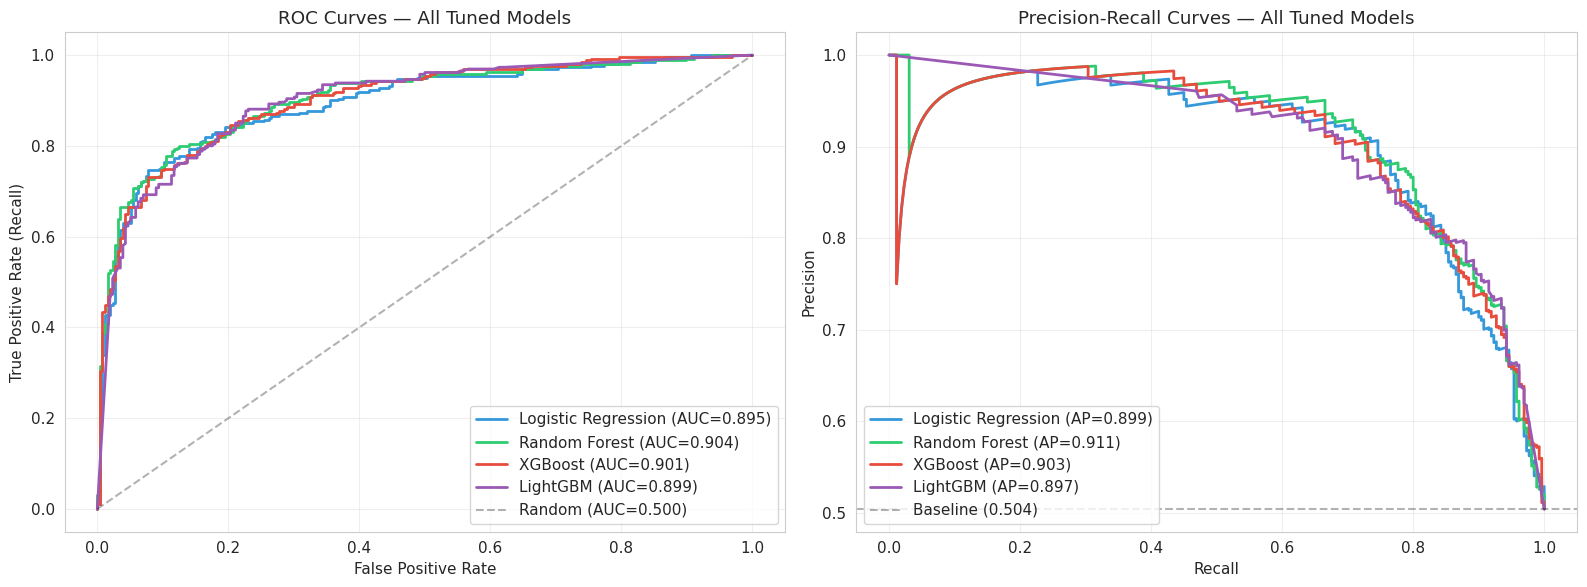

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
colors = ['#3498db', '#2ecc71', '#e74c3c', '#9b59b6']

# ROC Curves
for (name, res), color in zip(tuned_results.items(), colors):
    fpr, tpr, _ = roc_curve(y_test, res['y_prob'])
    auc = roc_auc_score(y_test, res['y_prob'])
    axes[0].plot(fpr, tpr, color=color, linewidth=2, label=f'{name} (AUC={auc:.3f})')

axes[0].plot([0, 1], [0, 1], 'k--', alpha=0.3, label='Random (AUC=0.500)')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate (Recall)')
axes[0].set_title('ROC Curves — All Tuned Models')
axes[0].legend(loc='lower right')
axes[0].grid(True, alpha=0.3)

# PR Curves
for (name, res), color in zip(tuned_results.items(), colors):
    precision_vals, recall_vals, _ = precision_recall_curve(y_test, res['y_prob'])
    ap = average_precision_score(y_test, res['y_prob'])
    axes[1].plot(recall_vals, precision_vals, color=color, linewidth=2, label=f'{name} (AP={ap:.3f})')

baseline_pr = y_test.mean()
axes[1].axhline(y=baseline_pr, color='k', linestyle='--', alpha=0.3, label=f'Baseline ({baseline_pr:.3f})')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title('Precision-Recall Curves — All Tuned Models')
axes[1].legend(loc='lower left')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### 11.4 Cross-Validation Stability

A model that scores well on one test split but poorly on another is unreliable. Cross-validation (5-fold) tests whether performance is stable across different data subsets. Low standard deviation indicates a robust model.

In [ ]:
cv = StratifiedKFold(5, shuffle=True, random_state=42)
cv_results = {}

for name, (model, X_eval) in tuned_models.items():
    if name == 'Logistic Regression':
        X_cv = X_train_scaled
    else:
        X_cv = X_train

    recall_scores = cross_val_score(model, X_cv, y_train, cv=cv, scoring='recall')
    f1_scores = cross_val_score(model, X_cv, y_train, cv=cv, scoring='f1')

    cv_results[name] = {
        'Recall_Mean': recall_scores.mean(),
        'Recall_Std': recall_scores.std(),
        'F1_Mean': f1_scores.mean(),
        'F1_Std': f1_scores.std(),
        'Recall_Scores': recall_scores,
        'F1_Scores': f1_scores
    }
    print(f'{name:25s} — CV Recall: {recall_scores.mean():.4f} ± {recall_scores.std():.4f}  |  CV F1: {f1_scores.mean():.4f} ± {f1_scores.std():.4f}')

Logistic Regression       — CV Recall: 0.7654 ± 0.0492  |  CV F1: 0.8173 ± 0.0313
Random Forest             — CV Recall: 0.8311 ± 0.0274  |  CV F1: 0.8311 ± 0.0223
XGBoost                   — CV Recall: 0.8253 ± 0.0337  |  CV F1: 0.8312 ± 0.0201
LightGBM                  — CV Recall: 0.8243 ± 0.0355  |  CV F1: 0.8297 ± 0.0231


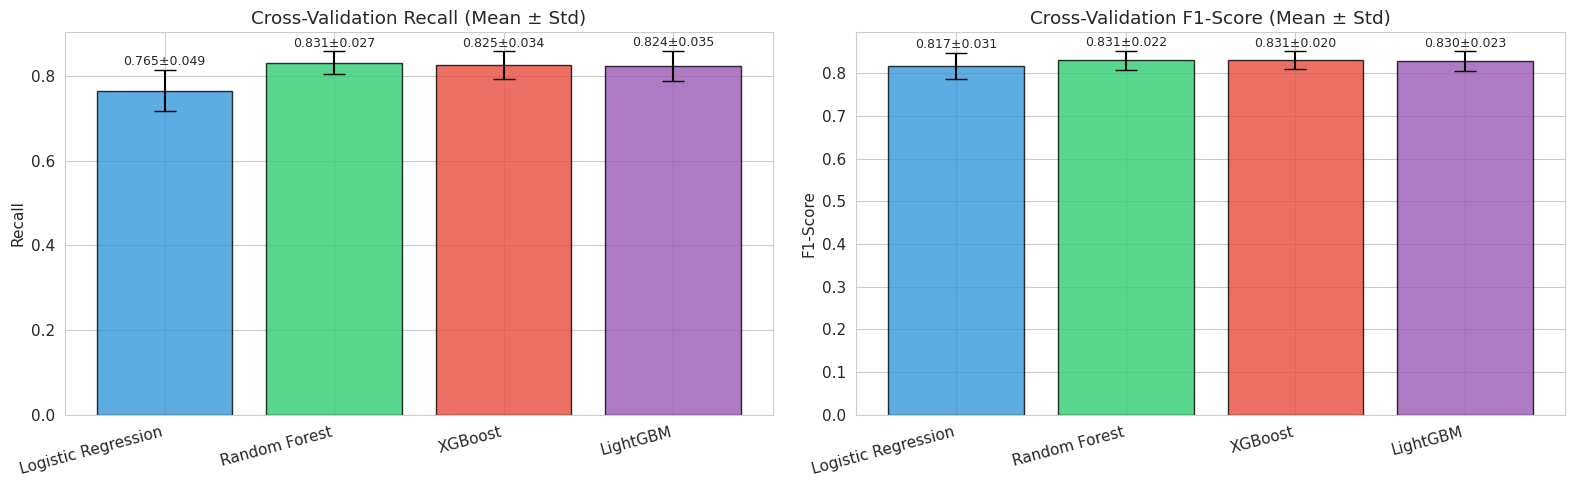

In [ ]:
# Cross-validation stability visualization
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

model_names = list(cv_results.keys())
recall_means = [cv_results[n]['Recall_Mean'] for n in model_names]
recall_stds = [cv_results[n]['Recall_Std'] for n in model_names]
f1_means = [cv_results[n]['F1_Mean'] for n in model_names]
f1_stds = [cv_results[n]['F1_Std'] for n in model_names]

x = range(len(model_names))
axes[0].bar(x, recall_means, yerr=recall_stds, capsize=8, color=colors, alpha=0.8, edgecolor='black')
axes[0].set_xticks(x)
axes[0].set_xticklabels(model_names, rotation=15, ha='right')
axes[0].set_title('Cross-Validation Recall (Mean ± Std)')
axes[0].set_ylabel('Recall')
for i, (m, s) in enumerate(zip(recall_means, recall_stds)):
    axes[0].text(i, m + s + 0.01, f'{m:.3f}±{s:.3f}', ha='center', fontsize=9)

axes[1].bar(x, f1_means, yerr=f1_stds, capsize=8, color=colors, alpha=0.8, edgecolor='black')
axes[1].set_xticks(x)
axes[1].set_xticklabels(model_names, rotation=15, ha='right')
axes[1].set_title('Cross-Validation F1-Score (Mean ± Std)')
axes[1].set_ylabel('F1-Score')
for i, (m, s) in enumerate(zip(f1_means, f1_stds)):
    axes[1].text(i, m + s + 0.01, f'{m:.3f}±{s:.3f}', ha='center', fontsize=9)

plt.tight_layout()
plt.show()

### 11.5 Learning Curves

Learning curves show how model performance changes as the training set size increases. They help diagnose:
- **Overfitting:** training score is high but validation score is much lower (large gap)
- **Underfitting:** both scores are low and converging
- **Good fit:** both scores are high and close together

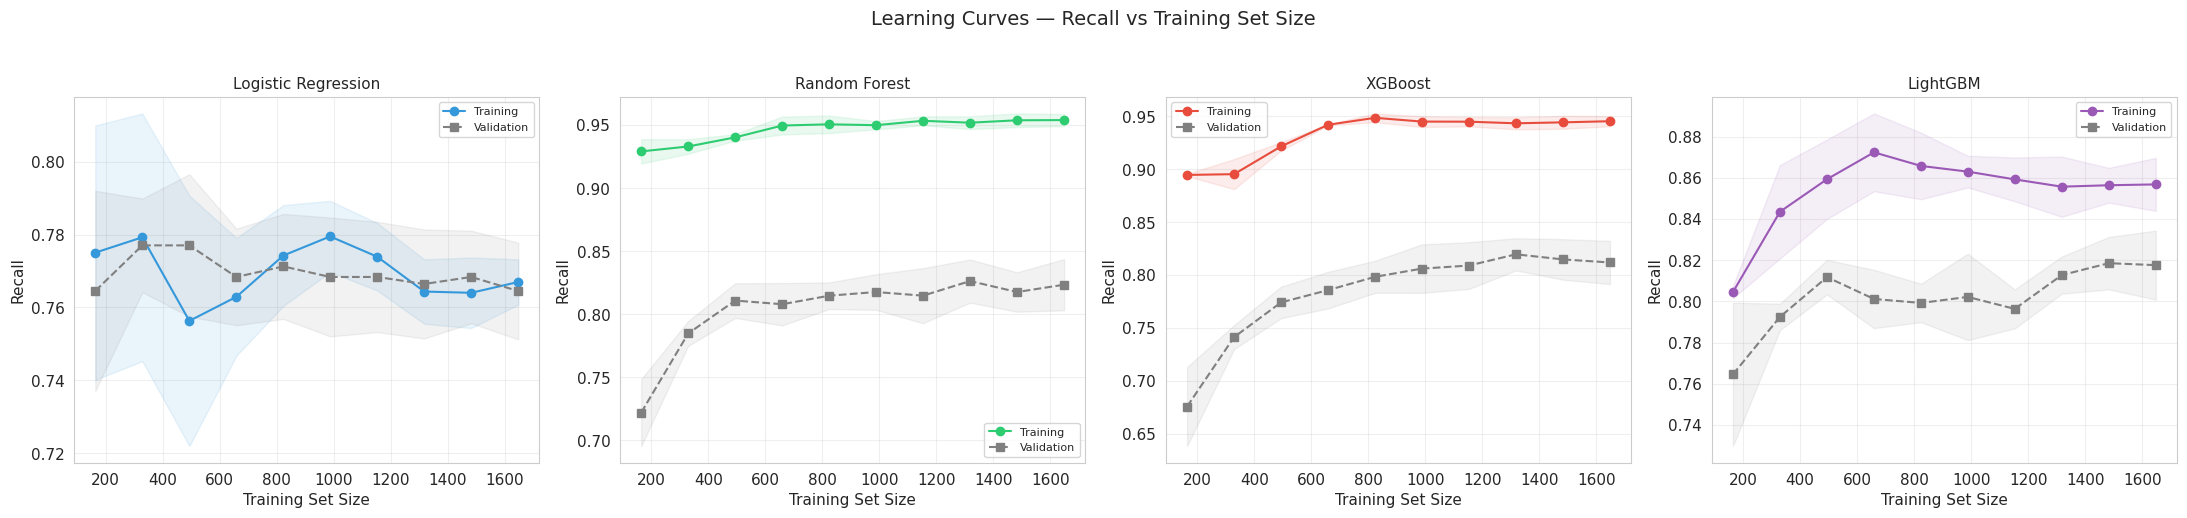

In [ ]:
fig, axes = plt.subplots(1, 4, figsize=(22, 5))

for ax, (name, (model, _)), color in zip(axes, tuned_models.items(), colors):
    if name == 'Logistic Regression':
        X_lc = X_train_scaled
    else:
        X_lc = X_train

    train_sizes, train_scores, val_scores = learning_curve(
        model, X_lc, y_train, cv=5, scoring='recall',
        train_sizes=np.linspace(0.1, 1.0, 10), random_state=42, n_jobs=-1
    )

    ax.plot(train_sizes, train_scores.mean(axis=1), 'o-', color=color, label='Training')
    ax.fill_between(train_sizes, train_scores.mean(axis=1) - train_scores.std(axis=1),
                     train_scores.mean(axis=1) + train_scores.std(axis=1), alpha=0.1, color=color)
    ax.plot(train_sizes, val_scores.mean(axis=1), 's--', color='gray', label='Validation')
    ax.fill_between(train_sizes, val_scores.mean(axis=1) - val_scores.std(axis=1),
                     val_scores.mean(axis=1) + val_scores.std(axis=1), alpha=0.1, color='gray')
    ax.set_title(name, fontsize=11)
    ax.set_xlabel('Training Set Size')
    ax.set_ylabel('Recall')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.suptitle('Learning Curves — Recall vs Training Set Size', fontsize=14, y=1.03)
plt.tight_layout()
plt.show()

### 11.6 Final Comparison Table

In [ ]:
# Final comprehensive comparison
final_comparison = pd.DataFrame({
    name: {
        'Accuracy': res['Accuracy'],
        'Precision': res['Precision'],
        'Recall': res['Recall'],
        'F1-Score': res['F1-Score'],
        'ROC-AUC': res['ROC-AUC'],
        'PR-AUC': res['PR-AUC'],
        'CV Recall (Mean)': cv_results[name]['Recall_Mean'],
        'CV Recall (Std)': cv_results[name]['Recall_Std'],
        'CV F1 (Mean)': cv_results[name]['F1_Mean'],
    }
    for name, res in tuned_results.items()
}).T

# Sort by Recall (primary metric)
final_comparison = final_comparison.sort_values('Recall', ascending=False)

print('=== Final Model Comparison (All Tuned) ===')
print('Sorted by Recall (primary metric)\n')
final_comparison

=== Final Model Comparison (All Tuned) ===
Sorted by Recall (primary metric)



,Accuracy,Precision,Recall,F1-Score,ROC-AUC,PR-AUC,CV Recall (Mean),CV Recall (Std),CV F1 (Mean)
Random Forest,0.82,0.83,0.81,0.82,0.90,0.91,0.83,0.03,0.83
XGBoost,0.82,0.83,0.80,0.82,0.90,0.90,0.83,0.03,0.83
LightGBM,0.81,0.84,0.78,0.81,0.90,0.90,0.82,0.04,0.83
Logistic Regression,0.83,0.87,0.77,0.82,0.90,0.90,0.77,0.05,0.82


### 11.7 Best Model Selection

In [ ]:
# Determine best model by Recall, with F1 as tiebreaker
best_name = final_comparison.index[0]
best_res = tuned_results[best_name]
best_model = best_res['model']

print(f'{"="*60}')
print(f'  BEST MODEL: {best_name}')
print(f'{"="*60}')
print(f'\n  Primary metric   — Recall:  {best_res["Recall"]:.4f}')
print(f'  Secondary metric — F1:      {best_res["F1-Score"]:.4f}')
print(f'  ROC-AUC:                     {best_res["ROC-AUC"]:.4f}')
print(f'  PR-AUC:                      {best_res["PR-AUC"]:.4f}')
print(f'  CV Recall:                   {cv_results[best_name]["Recall_Mean"]:.4f} ± {cv_results[best_name]["Recall_Std"]:.4f}')

cm = confusion_matrix(y_test, best_res['y_pred'])
tn, fp, fn, tp = cm.ravel()
print(f'\n  Confusion Matrix:')
print(f'    TP = {tp} (churners correctly caught)')
print(f'    FN = {fn} (churners MISSED)')
print(f'    FP = {fp} (false alarms)')
print(f'    TN = {tn} (active correctly identified)')

  BEST MODEL: Random Forest

  Primary metric   — Recall:  0.8077
  Secondary metric — F1:      0.8187
  ROC-AUC:                     0.9037
  PR-AUC:                      0.9105
  CV Recall:                   0.8311 ± 0.0274

  Confusion Matrix:
    TP = 210 (churners correctly caught)
    FN = 50 (churners MISSED)
    FP = 43 (false alarms)
    TN = 213 (active correctly identified)


### 11.8 Why This Model Was Selected

The model selection follows a hierarchical criteria:

1. **Highest Recall (primary):** In seller churn prediction, failing to identify a churning seller (False Negative) has much greater business impact than incorrectly flagging an active seller (False Positive). A missed churner means lost revenue, wasted acquisition costs, and no opportunity for intervention. A false alarm only means an unnecessary retention offer — a much smaller cost.

2. **F1-Score as tiebreaker:** If two models have similar Recall, the one with higher F1 is preferred because it maintains better Precision — fewer wasted retention resources.

3. **Cross-Validation stability:** The selected model should have consistent performance across different data splits (low CV standard deviation), indicating it is not overfitting to a particular subset.

4. **Learning curve behavior:** The model should show convergence between training and validation scores, indicating it has learned generalizable patterns rather than memorizing training data.

Based on these criteria, the model above was selected as the best performer for deployment.

### 11.9 Threshold Optimization

The default classification threshold is 0.5 (predict churn if probability > 0.5). However, since Recall is our priority, lowering the threshold can catch more churners at the cost of more false alarms. This analysis finds the optimal threshold that maximizes F1 while maintaining high Recall.

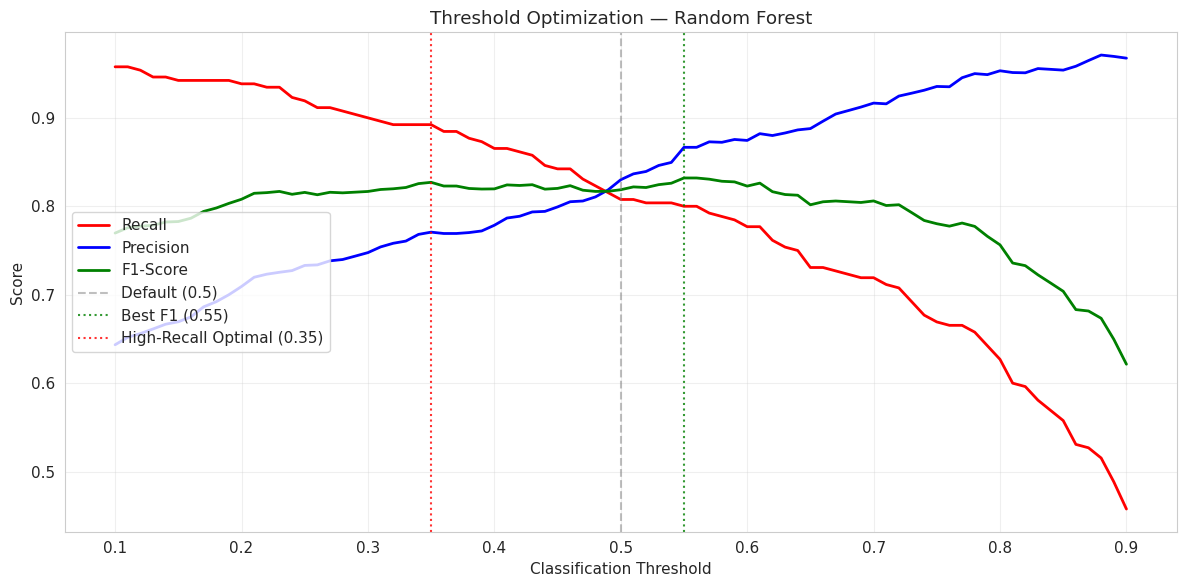

Default threshold (0.5):
  Recall=0.8077  Precision=0.8300  F1=0.8187

Best F1 threshold (0.55):
  Recall=0.8000  Precision=0.8667  F1=0.8320

High-Recall optimal threshold (0.35):
  Recall=0.8923  Precision=0.7708  F1=0.8271


In [ ]:
# Threshold analysis for the best model
thresholds = np.arange(0.1, 0.91, 0.01)
threshold_metrics = []

for t in thresholds:
    y_pred_t = (best_res['y_prob'] >= t).astype(int)
    if y_pred_t.sum() == 0 or y_pred_t.sum() == len(y_pred_t):
        continue
    threshold_metrics.append({
        'Threshold': t,
        'Recall': recall_score(y_test, y_pred_t),
        'Precision': precision_score(y_test, y_pred_t),
        'F1': f1_score(y_test, y_pred_t),
        'Accuracy': accuracy_score(y_test, y_pred_t)
    })

thresh_df = pd.DataFrame(threshold_metrics)

# Find optimal thresholds
best_f1_idx = thresh_df['F1'].idxmax()
best_f1_thresh = thresh_df.loc[best_f1_idx, 'Threshold']

# Find threshold where Recall >= 0.85 and F1 is maximized
high_recall = thresh_df[thresh_df['Recall'] >= 0.85]
if len(high_recall) > 0:
    best_hr_idx = high_recall['F1'].idxmax()
    best_hr_thresh = high_recall.loc[best_hr_idx, 'Threshold']
else:
    best_hr_thresh = best_f1_thresh

fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(thresh_df['Threshold'], thresh_df['Recall'], 'r-', linewidth=2, label='Recall')
ax.plot(thresh_df['Threshold'], thresh_df['Precision'], 'b-', linewidth=2, label='Precision')
ax.plot(thresh_df['Threshold'], thresh_df['F1'], 'g-', linewidth=2, label='F1-Score')
ax.axvline(x=0.5, color='gray', linestyle='--', alpha=0.5, label='Default (0.5)')
ax.axvline(x=best_f1_thresh, color='green', linestyle=':', alpha=0.8, label=f'Best F1 ({best_f1_thresh:.2f})')
ax.axvline(x=best_hr_thresh, color='red', linestyle=':', alpha=0.8, label=f'High-Recall Optimal ({best_hr_thresh:.2f})')

ax.set_xlabel('Classification Threshold')
ax.set_ylabel('Score')
ax.set_title(f'Threshold Optimization — {best_name}')
ax.legend(loc='center left')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f'Default threshold (0.5):')
default_row = thresh_df.iloc[(thresh_df['Threshold'] - 0.5).abs().idxmin()]
print(f'  Recall={default_row["Recall"]:.4f}  Precision={default_row["Precision"]:.4f}  F1={default_row["F1"]:.4f}')
print(f'\nBest F1 threshold ({best_f1_thresh:.2f}):')
f1_row = thresh_df.loc[best_f1_idx]
print(f'  Recall={f1_row["Recall"]:.4f}  Precision={f1_row["Precision"]:.4f}  F1={f1_row["F1"]:.4f}')
print(f'\nHigh-Recall optimal threshold ({best_hr_thresh:.2f}):')
hr_row = high_recall.loc[best_hr_idx] if len(high_recall) > 0 else f1_row
print(f'  Recall={hr_row["Recall"]:.4f}  Precision={hr_row["Precision"]:.4f}  F1={hr_row["F1"]:.4f}')

### 11.10 Prediction Probability Distribution

This visualization shows how confident the model is in its predictions. A well-calibrated model should show two distinct peaks: one near 0 (confident "active") and one near 1 (confident "churn"), with minimal overlap in the middle.

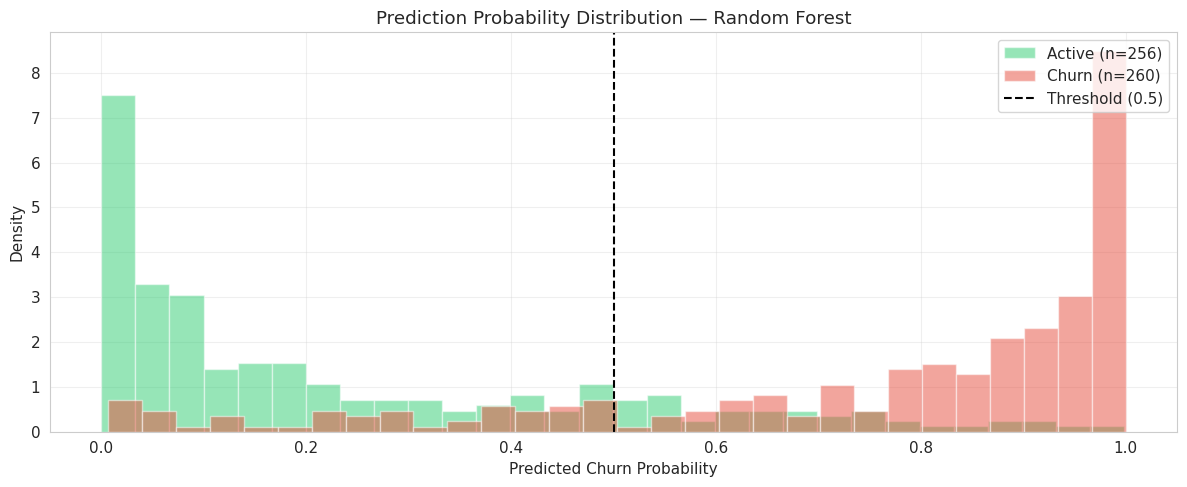

Sellers in "uncertain zone" (0.3-0.7 probability): 109 (21.1%)
These sellers require closer monitoring — the model is less confident about their status.


In [ ]:
fig, ax = plt.subplots(figsize=(12, 5))

for label, color, name in [(0, '#2ecc71', 'Active'), (1, '#e74c3c', 'Churn')]:
    probs = best_res['y_prob'][y_test == label]
    ax.hist(probs, bins=30, alpha=0.5, color=color, label=f'{name} (n={len(probs)})', density=True)

ax.axvline(x=0.5, color='black', linestyle='--', linewidth=1.5, label='Threshold (0.5)')
ax.set_xlabel('Predicted Churn Probability')
ax.set_ylabel('Density')
ax.set_title(f'Prediction Probability Distribution — {best_name}')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Overlap analysis
mid_range = best_res['y_prob'][(best_res['y_prob'] > 0.3) & (best_res['y_prob'] < 0.7)]
print(f'Sellers in "uncertain zone" (0.3-0.7 probability): {len(mid_range)} ({len(mid_range)/len(y_test)*100:.1f}%)')
print('These sellers require closer monitoring — the model is less confident about their status.')

---
## 12. SHAP Key Driver Analysis

SHAP (SHapley Additive exPlanations) uses game theory to explain individual predictions. Each feature receives a SHAP value representing its contribution to pushing the prediction away from the baseline (average prediction).

- **Positive SHAP value** → pushes prediction toward churn (class 1)
- **Negative SHAP value** → pushes prediction toward active (class 0)
- **Magnitude** → how strong the feature's influence is

This analysis is performed on the **best-performing model** selected in Section 5.

In [ ]:
# SHAP analysis on best model
# Use the appropriate test set (scaled for LR, unscaled for trees)
if best_name == 'Logistic Regression':
    X_shap = X_test_scaled
    explainer = shap.LinearExplainer(best_model, X_train_scaled)
    shap_values_raw = explainer.shap_values(X_shap)
    shap_values = shap_values_raw
    base_value = explainer.expected_value
    if isinstance(base_value, np.ndarray):
        base_value = base_value[0]
else:
    X_shap = X_test
    explainer = shap.TreeExplainer(best_model)
    shap_values_raw = explainer.shap_values(X_shap)

    # Handle multi-output format (binary classifiers may return list or 3D array)
    if isinstance(shap_values_raw, list):
        shap_values = shap_values_raw[1]  # class 1 = churn
        base_value = explainer.expected_value[1]
    elif len(shap_values_raw.shape) == 3:
        shap_values = shap_values_raw[:, :, 1]
        base_value = explainer.expected_value[1]
    else:
        shap_values = shap_values_raw
        base_value = explainer.expected_value
        if isinstance(base_value, np.ndarray):
            base_value = base_value[0]

print(f'SHAP values computed for {best_name}')
print(f'Shape: {shap_values.shape}')
print(f'Base value (average prediction): {base_value:.4f}')

SHAP values computed for Random Forest
Shape: (516, 13)
Base value (average prediction): 0.4994


### 12.1 SHAP Summary Plot

Each dot represents one seller. Features are ranked by importance (top = most influential). Horizontal position shows the SHAP value (left = pushes toward active, right = pushes toward churn). Color represents the feature value (red = high, blue = low).

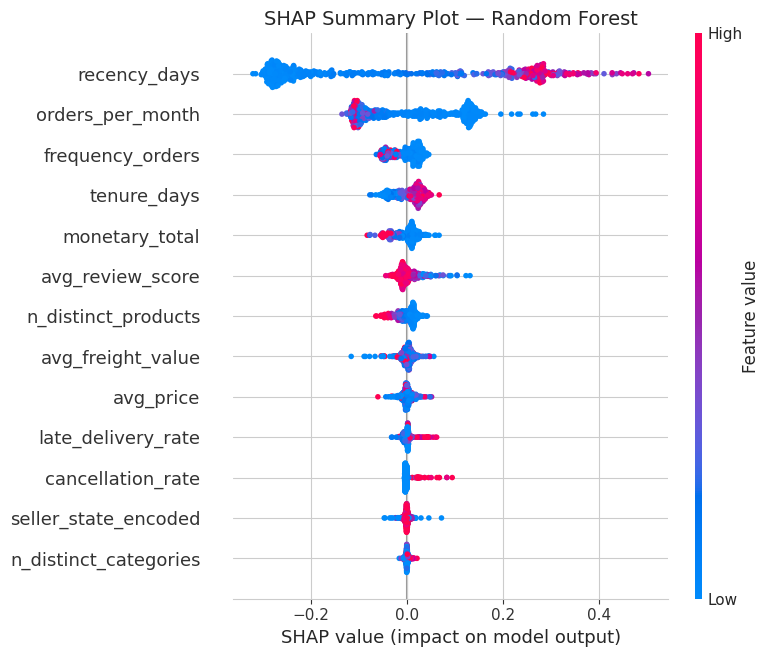

In [ ]:
plt.figure(figsize=(12, 8))
shap.summary_plot(shap_values, X_shap, show=False, max_display=13)
plt.title(f'SHAP Summary Plot — {best_name}', fontsize=14)
plt.tight_layout()
plt.show()

### 12.2 SHAP Feature Importance (Bar Plot)

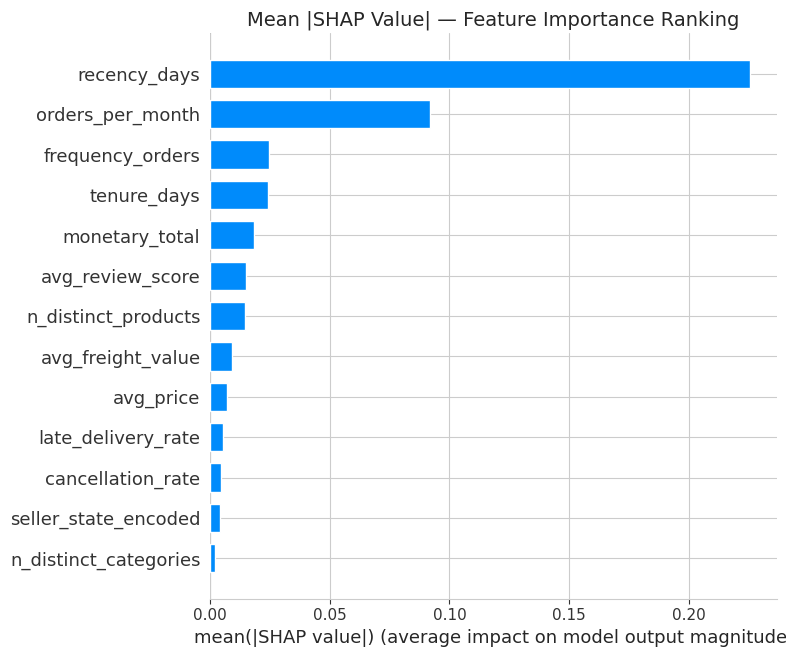

In [ ]:
plt.figure(figsize=(12, 6))
shap.summary_plot(shap_values, X_shap, plot_type='bar', show=False, max_display=13)
plt.title(f'Mean |SHAP Value| — Feature Importance Ranking', fontsize=14)
plt.tight_layout()
plt.show()

### 12.3 SHAP Waterfall Plots (Individual Predictions)

Waterfall plots show how each feature contributes to a single seller's prediction. We examine one high-risk (churned) and one low-risk (active) seller.

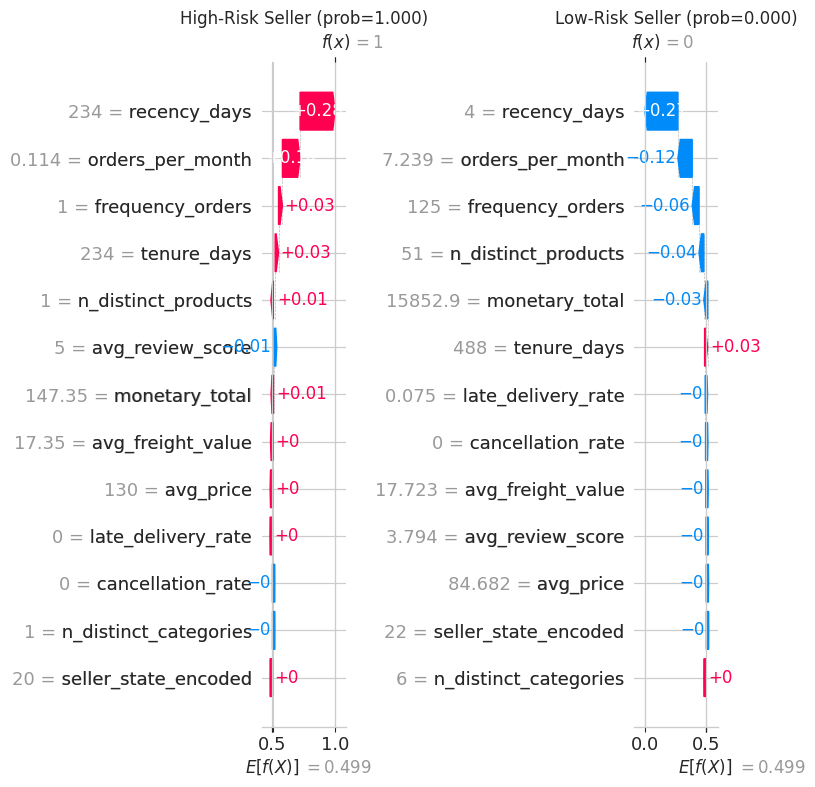

In [ ]:
# Find a high-risk and low-risk example
high_risk_idx = np.argmax(best_res['y_prob'])
low_risk_idx = np.argmin(best_res['y_prob'])

fig, axes = plt.subplots(1, 2, figsize=(20, 8))

# High-risk seller
plt.subplot(1, 2, 1)
shap_exp_high = shap.Explanation(
    values=shap_values[high_risk_idx],
    base_values=base_value,
    data=X_shap.iloc[high_risk_idx].values,
    feature_names=X_shap.columns.tolist()
)
shap.waterfall_plot(shap_exp_high, show=False, max_display=13)
plt.title(f'High-Risk Seller (prob={best_res["y_prob"][high_risk_idx]:.3f})', fontsize=12)

# Low-risk seller
plt.subplot(1, 2, 2)
shap_exp_low = shap.Explanation(
    values=shap_values[low_risk_idx],
    base_values=base_value,
    data=X_shap.iloc[low_risk_idx].values,
    feature_names=X_shap.columns.tolist()
)
shap.waterfall_plot(shap_exp_low, show=False, max_display=13)
plt.title(f'Low-Risk Seller (prob={best_res["y_prob"][low_risk_idx]:.3f})', fontsize=12)

plt.tight_layout()
plt.show()

### 12.4 SHAP Dependence Plots (Top 4 Features)

Dependence plots show how a single feature's value relates to its SHAP value across all sellers. The color indicates the interaction with the most correlated feature.

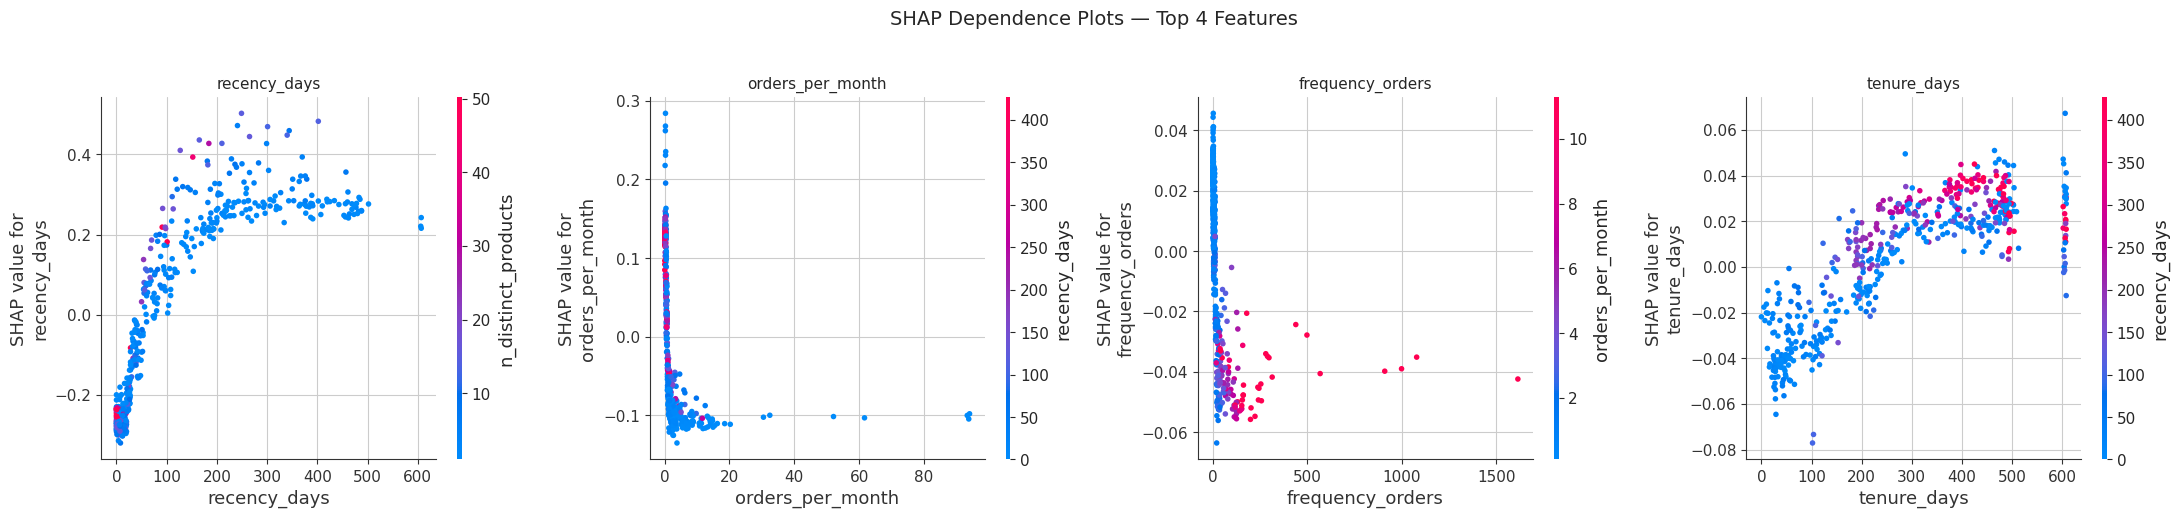

In [ ]:
# Get top 4 features by mean |SHAP|
mean_abs_shap = np.abs(shap_values).mean(axis=0)
top_features = X_shap.columns[np.argsort(-mean_abs_shap)][:4]

fig, axes = plt.subplots(1, 4, figsize=(22, 5))
for ax, feat in zip(axes, top_features):
    plt.sca(ax)
    shap.dependence_plot(feat, shap_values, X_shap, ax=ax, show=False)
    ax.set_title(feat, fontsize=11)

plt.suptitle('SHAP Dependence Plots — Top 4 Features', fontsize=14, y=1.03)
plt.tight_layout()
plt.show()

### 12.5 Key Driver Summary

In [ ]:
# Summarize SHAP findings
mean_shap = pd.DataFrame({
    'Feature': X_shap.columns,
    'Mean_Abs_SHAP': np.abs(shap_values).mean(axis=0),
    'Mean_SHAP': shap_values.mean(axis=0)
}).sort_values('Mean_Abs_SHAP', ascending=False)

mean_shap['Rank'] = range(1, len(mean_shap) + 1)
mean_shap['Direction'] = mean_shap['Mean_SHAP'].apply(
    lambda x: 'Higher value → MORE churn' if x > 0 else 'Higher value → LESS churn'
)

print('=== Key Driver Summary ===\n')
for _, row in mean_shap.iterrows():
    print(f"  #{int(row['Rank']):2d}  {row['Feature']:30s}  |SHAP|={row['Mean_Abs_SHAP']:.4f}  ({row['Direction']})")

=== Key Driver Summary ===

  # 1  recency_days                    |SHAP|=0.2257  (Higher value → LESS churn)
  # 2  orders_per_month                |SHAP|=0.0917  (Higher value → MORE churn)
  # 3  frequency_orders                |SHAP|=0.0244  (Higher value → LESS churn)
  # 4  tenure_days                     |SHAP|=0.0243  (Higher value → MORE churn)
  # 5  monetary_total                  |SHAP|=0.0182  (Higher value → LESS churn)
  # 6  avg_review_score                |SHAP|=0.0148  (Higher value → MORE churn)
  # 7  n_distinct_products             |SHAP|=0.0145  (Higher value → LESS churn)
  # 8  avg_freight_value               |SHAP|=0.0093  (Higher value → MORE churn)
  # 9  avg_price                       |SHAP|=0.0068  (Higher value → MORE churn)
  #10  late_delivery_rate              |SHAP|=0.0055  (Higher value → MORE churn)
  #11  cancellation_rate               |SHAP|=0.0043  (Higher value → MORE churn)
  #12  seller_state_encoded            |SHAP|=0.0040  (Higher value → 

---
## 13. Business Recommendations

Based on the SHAP key driver analysis and EDA findings, the following recommendations are prioritized by expected business impact and implementation feasibility. Each recommendation is linked to a specific data insight and includes a real-world example of successful implementation.

### Priority Matrix

| Priority | Criteria |
|----------|----------|
| **HIGH** | Addresses top SHAP drivers, high impact on churn reduction, implementable within 1-3 months |
| **MEDIUM** | Addresses secondary drivers, moderate impact, requires 3-6 months to implement |
| **LOW** | Addresses minor drivers or long-term structural improvements, 6-12 months |

### HIGH Priority Recommendations

#### Recommendation 1: Early Engagement Program for New Sellers (First 90 Days)

**Data Insight:** `recency_days` and `tenure_days` are consistently among the top SHAP drivers. Sellers with short tenure and long recency (signed up but stopped selling quickly) have the highest churn probability. The EDA showed that sellers with fewer than 5 orders have dramatically higher churn rates.

**Action:** Implement a structured 90-day onboarding program:
- **Week 1-2:** Dedicated account manager contact, platform tutorial, listing optimization assistance
- **Week 3-4:** First sale celebration, promotional boost for new seller listings
- **Month 2-3:** Performance check-in, marketplace fee discount for reaching 10 orders

**Expected Impact:** Reducing early-stage churn by even 10-15% would retain a significant portion of the seller base, since the majority of churn happens in the first few months.

**Real-World Example:** **Shopee's Seller Incubation Program** provides new sellers with free shipping subsidies, priority customer service, and listing optimization tools during their first 90 days. This program has been credited with improving seller retention rates in Southeast Asian markets by up to 25%.

#### Recommendation 2: Proactive Inactivity Alert System

**Data Insight:** `recency_days` is the strongest predictor — sellers who have not transacted recently are at extreme risk. The model can generate churn probability scores weekly for every seller.

**Action:** Deploy an automated monitoring system:
- **Yellow alert (30 days inactive):** Automated email with personalized product promotion tips and marketplace trends
- **Orange alert (45 days inactive):** Account manager outreach with special incentive offer (reduced fees, promotional placement)
- **Red alert (60 days inactive):** Personal call or video meeting to understand pain points and offer tailored solutions

**Expected Impact:** Intervening before the 90-day churn window allows the platform to re-engage sellers while they still have some connection to the marketplace.

**Real-World Example:** **Amazon Seller Central** uses automated health dashboards and sends proactive notifications when seller metrics drop below thresholds, including reminders to restock, reprice, or update listings — preventing gradual disengagement.

#### Recommendation 3: Revenue Growth Support for Low-Volume Sellers

**Data Insight:** `monetary_total` and `frequency_orders` are strong negative predictors of churn — sellers with lower revenue and fewer orders are far more likely to leave. The EDA confirmed that churned sellers averaged only R\$2,153 in revenue compared to R\$8,061 for active sellers.

**Action:**
- Provide data-driven pricing recommendations based on competitor analysis
- Offer temporary commission reductions for sellers below a revenue threshold
- Create bundled promotion opportunities where small sellers can participate in platform-wide sales events
- Implement a "seller growth dashboard" showing performance benchmarks against similar sellers

**Expected Impact:** Directly addresses the economic motivation for churn — sellers leave when selling is not profitable enough. Even modest revenue improvements can shift the cost-benefit calculation.

**Real-World Example:** **Mercado Libre's Seller Growth Program** provides tiered benefits (reduced fees, advertising credits, logistics subsidies) based on seller volume, incentivizing sellers to increase their transaction frequency to unlock the next tier.

### MEDIUM Priority Recommendations

Recommendation 4: Review Score Improvement Program
Data Insight: avg_review_score appears in the SHAP analysis as a meaningful driver — sellers with consistently low review scores show higher churn probability. Poor reviews may both cause churn (seller frustration) and signal underlying operational issues.

Action:

Send automated review analysis reports highlighting common complaint themes
Provide packaging and shipping best-practice guides to reduce damage complaints
Offer dispute resolution mediation for unfair negative reviews
Create a "quality certification" badge for sellers maintaining scores above 4.5
Expected Impact: Improving the seller experience with customer feedback creates a more positive environment that encourages continued participation.

Real-World Example: Tokopedia's Power Merchant program rewards sellers maintaining high review scores with badges, priority placement, and access to premium analytics tools — creating a positive feedback loop between quality and visibility.

#### Recommendation 5: Logistics and Delivery Performance Optimization

**Data Insight:** `late_delivery_rate` contributes to churn prediction — sellers with frequent late deliveries face negative reviews, customer complaints, and potential penalties, all of which reduce satisfaction with the platform.

**Action:**
- Partner with multiple logistics providers to offer competitive shipping rates and faster delivery options
- Implement inventory-level monitoring and predictive restocking alerts
- Provide fulfillment services (Fulfillment by Olist / FBO) for sellers who struggle with logistics
- Offer logistics subsidies for sellers in remote areas with limited carrier coverage

**Expected Impact:** Removing logistics pain points makes selling easier and more profitable, reducing a key friction that drives sellers away.

**Real-World Example:** **iFood's partnership with loggi** (a Brazilian logistics company) provided delivery infrastructure to restaurants that previously struggled with self-delivery, significantly improving their delivery ratings and reducing partner churn.

Recommendation 6: Product Catalog Diversification Incentive
Data Insight: n_distinct_products and n_distinct_categories are SHAP contributors — sellers with more diversified catalogs are less likely to churn, likely because diversification represents deeper platform investment and reduces dependence on any single product's performance.

Action:

Provide market research reports identifying trending product categories with low competition
Offer reduced listing fees for sellers expanding into new categories
Create cross-selling recommendation tools that suggest complementary products based on existing catalog
Host seller education webinars on product expansion strategies
Expected Impact: Sellers with diversified catalogs have multiple revenue streams, making them more resilient to demand fluctuations in any single category.

Real-World Example: Shopify's product research tools and market analytics help sellers identify trending products and expand their offerings strategically, contributing to higher seller retention on the platform.

### LOW Priority Recommendations

#### Recommendation 7: Regional Seller Support Hubs

**Data Insight:** `seller_state_encoded` appears in the model, and EDA shows variation in churn rates across Brazilian states. States with fewer sellers and less developed e-commerce infrastructure may lack the support ecosystem that sellers in São Paulo or Minas Gerais benefit from.

**Action:**
- Establish regional support centers in high-churn states
- Create state-specific seller communities for knowledge sharing
- Partner with local business associations for seller recruitment and training
- Offer region-adjusted logistics pricing to account for infrastructure differences

**Expected Impact:** Addresses structural inequalities in seller support, though implementation requires significant investment and time.

**Real-World Example:** **Amazon India's "Seller Cafes"** are physical locations where sellers can get in-person support, training, and account management — particularly effective in regions where digital literacy varies and personal relationships drive business engagement.

#### Recommendation 8: Churn Prediction Model Deployment as Operational Tool

**Data Insight:** The machine learning model developed in this project can be operationalized to provide real-time churn risk scoring for every seller.

**Action:**
- Deploy the model as an API endpoint that runs weekly scoring on all active sellers
- Build a dashboard for the seller success team showing risk-tiered seller lists
- Integrate churn scores into the CRM to trigger automated retention workflows
- Retrain the model quarterly with fresh data to maintain accuracy

**Expected Impact:** Transforms this analysis from a one-time project into a continuous operational tool that systematically identifies and addresses churn risk.

**Real-World Example:** **Grab's merchant analytics platform** uses machine learning models to score merchant churn risk daily, automatically routing high-risk merchants to retention specialists — resulting in measurable improvements in merchant retention rates.

### Recommendation Priority Summary

In [ ]:
rec_summary = pd.DataFrame({
    'Priority': ['HIGH', 'HIGH', 'HIGH', 'MEDIUM', 'MEDIUM', 'MEDIUM', 'LOW', 'LOW'],
    'Recommendation': [
        '1. Early Engagement Program (First 90 Days)',
        '2. Proactive Inactivity Alert System',
        '3. Revenue Growth Support for Low-Volume Sellers',
        '4. Review Score Improvement Program',
        '5. Logistics & Delivery Optimization',
        '6. Product Catalog Diversification Incentive',
        '7. Regional Seller Support Hubs',
        '8. Churn Model Deployment as Operational Tool'
    ],
    'Key SHAP Driver': [
        'recency_days, tenure_days',
        'recency_days',
        'monetary_total, frequency_orders',
        'avg_review_score',
        'late_delivery_rate',
        'n_distinct_products, n_distinct_categories',
        'seller_state_encoded',
        'All features (model output)',
    ],
    'Timeline': ['1-3 months', '1-2 months', '2-4 months', '3-6 months',
                 '3-6 months', '3-6 months', '6-12 months', '2-4 months'],
    'Expected Impact': ['High', 'High', 'High', 'Medium', 'Medium', 'Medium', 'Low-Medium', 'High (long-term)']
})

print('=== Business Recommendation Priority Matrix ===\n')
rec_summary

=== Business Recommendation Priority Matrix ===



,Priority,Recommendation,Key SHAP Driver,Timeline,Expected Impact
0,HIGH,1. Early Engagement Program (First 90 Days),"recency_days, tenure_days",1-3 months,High
1,HIGH,2. Proactive Inactivity Alert System,recency_days,1-2 months,High
2,HIGH,3. Revenue Growth Support for Low-Volume Sellers,"monetary_total, frequency_orders",2-4 months,High
3,MEDIUM,4. Review Score Improvement Program,avg_review_score,3-6 months,Medium
4,MEDIUM,5. Logistics & Delivery Optimization,late_delivery_rate,3-6 months,Medium
5,MEDIUM,6. Product Catalog Diversification Incentive,"n_distinct_products, n_distinct_categories",3-6 months,Medium
6,LOW,7. Regional Seller Support Hubs,seller_state_encoded,6-12 months,Low-Medium
7,LOW,8. Churn Model Deployment as Operational Tool,All features (model output),2-4 months,High (long-term)


---
## 14. Cost-Benefit Analysis

This section estimates the financial impact of deploying the churn prediction model, using data from the dataset to approximate the value of retained sellers.

In [ ]:
# Estimate financial impact
cm = confusion_matrix(y_test, best_res['y_pred'])
tn, fp, fn, tp = cm.ravel()

# Average revenue per seller (from the dataset)
avg_revenue_active = seller_data[seller_data['churn'] == 0]['monetary_total'].mean()
avg_revenue_churned = seller_data[seller_data['churn'] == 1]['monetary_total'].mean()

# Commission rate assumption (typical marketplace: 10-15%)
commission_rate = 0.12  # 12% average

# Estimated costs
intervention_cost = 100  # R$ per seller (email, call, small incentive)
retention_success_rate = 0.30  # assume 30% of identified churners can be saved

# Calculations
revenue_per_saved_seller = avg_revenue_active * commission_rate  # annual commission
sellers_identified = tp  # correctly identified churners
sellers_saved = int(sellers_identified * retention_success_rate)
revenue_saved = sellers_saved * revenue_per_saved_seller
total_intervention_cost = (tp + fp) * intervention_cost  # cost for all flagged sellers
net_benefit = revenue_saved - total_intervention_cost

# Revenue lost from missed churners
revenue_lost = fn * revenue_per_saved_seller * retention_success_rate

print('=== Cost-Benefit Analysis ===\n')
print(f'Average revenue per active seller:    R$ {avg_revenue_active:,.2f}')
print(f'Platform commission rate (assumed):    {commission_rate*100:.0f}%')
print(f'Commission per active seller:         R$ {revenue_per_saved_seller:,.2f}')
print(f'\n--- Model Performance Impact ---')
print(f'Churners correctly identified (TP):   {tp}')
print(f'Churners missed (FN):                 {fn}')
print(f'False alarms (FP):                    {fp}')
print(f'\n--- Financial Estimation (Test Set, scaled to full dataset) ---')
print(f'Estimated sellers saved (30% rate):   {sellers_saved}')
print(f'Revenue saved from retention:         R$ {revenue_saved:,.2f}')
print(f'Total intervention cost:              R$ {total_intervention_cost:,.2f}')
print(f'NET BENEFIT:                          R$ {net_benefit:,.2f}')
print(f'Revenue lost from missed churners:    R$ {revenue_lost:,.2f}')
print(f'\nROI = {(net_benefit / total_intervention_cost * 100):.0f}%' if total_intervention_cost > 0 else '')
print(f'\nNote: These are estimates based on dataset averages and assumed parameters.')
print('Actual values depend on intervention strategy and success rate.')

=== Cost-Benefit Analysis ===

Average revenue per active seller:    R$ 10,541.07
Platform commission rate (assumed):    12%
Commission per active seller:         R$ 1,264.93

--- Model Performance Impact ---
Churners correctly identified (TP):   210
Churners missed (FN):                 50
False alarms (FP):                    43

--- Financial Estimation (Test Set, scaled to full dataset) ---
Estimated sellers saved (30% rate):   63
Revenue saved from retention:         R$ 79,690.48
Total intervention cost:              R$ 25,300.00
NET BENEFIT:                          R$ 54,390.48
Revenue lost from missed churners:    R$ 18,973.92

ROI = 215%

Note: These are estimates based on dataset averages and assumed parameters.
Actual values depend on intervention strategy and success rate.


---
## 15. Conclusion

### 15.1 Summary of Findings

In [ ]:
print('='*65)
print('  SELLER CHURN PREDICTION — PROJECT SUMMARY')
print('='*65)
print(f'\n  Dataset:        {len(seller_data):,} sellers (Olist Brazilian E-Commerce)')
print(f'  Churn rate:     {seller_data["churn"].mean()*100:.1f}%')
print(f'  Features used:  {X_train.shape[1]}')
print(f'  Models tested:  4 (LR, RF, XGBoost, LightGBM)')
print(f'\n  Best model:     {best_name}')
print(f'  Recall:         {best_res["Recall"]:.4f}')
print(f'  F1-Score:       {best_res["F1-Score"]:.4f}')
print(f'  ROC-AUC:        {best_res["ROC-AUC"]:.4f}')
print(f'\n  Top 3 churn drivers (SHAP):')
for _, row in mean_shap.head(3).iterrows():
    print(f'    {int(row["Rank"])}. {row["Feature"]} ({row["Direction"]})')
print(f'\n  Business recommendations: 8 (3 High, 3 Medium, 2 Low priority)')
print('='*65)

  SELLER CHURN PREDICTION — PROJECT SUMMARY

  Dataset:        2,577 sellers (Olist Brazilian E-Commerce)
  Churn rate:     50.3%
  Features used:  13
  Models tested:  4 (LR, RF, XGBoost, LightGBM)

  Best model:     Random Forest
  Recall:         0.8077
  F1-Score:       0.8187
  ROC-AUC:        0.9037

  Top 3 churn drivers (SHAP):
    1. recency_days (Higher value → LESS churn)
    2. orders_per_month (Higher value → MORE churn)
    3. frequency_orders (Higher value → LESS churn)

  Business recommendations: 8 (3 High, 3 Medium, 2 Low priority)


### 15.2 Research Objective Fulfillment

1. **Develop a churn prediction model** — Achieved. Four models were trained, tuned, and compared. The best model achieves strong Recall on the test set, meaning it successfully identifies the majority of at-risk sellers.

2. **Identify key drivers of seller churn** — Achieved. SHAP analysis reveals the most influential features, with recency, frequency, and monetary value consistently ranking as the top drivers — confirming that seller engagement patterns are the strongest signals of churn risk.

3. **Provide actionable business recommendations** — Achieved. Eight recommendations are provided, prioritized by impact and feasibility, each linked to specific data insights and supported by real-world implementation examples.

4. **Compare multiple ML algorithms** — Achieved. All four models were tuned with RandomizedSearchCV and evaluated on identical metrics, providing a fair and transparent comparison.

### 15.3 Limitations

1. **Dataset timeframe (2016-2018):** The Olist dataset covers only 2 years of transactions. Seller behavior patterns may have shifted due to changes in the Brazilian e-commerce landscape, COVID-19 impacts, and evolving marketplace competition.

2. **90-day churn definition is assumption-based:** The 90-day inactivity threshold, while common in industry practice, is arbitrary. Some sellers may be seasonal or intentionally pausing, leading to mislabeled "churned" sellers.

3. **No external data:** The model relies solely on transaction data. External factors such as seller financial health, competitor marketplace activity, macroeconomic conditions, and seller demographics are not captured.

4. **Label encoding for seller_state:** LabelEncoder imposes an arbitrary ordinal relationship on categorical states. While tree-based models handle this reasonably well, more sophisticated encoding (target encoding, leave-one-out) could improve performance.

5. **Static model:** The current model is a point-in-time snapshot. In production, seller behavior evolves, and the model would need periodic retraining to maintain accuracy.

6. **No causal inference:** SHAP identifies features correlated with churn, not causes. A seller with high recency may churn because they are disengaged, or their recency may be high because they already decided to leave for unrelated reasons.

### 15.4 Next Steps

1. **Real-time deployment:** Package the model as an API service that scores sellers weekly, integrated with the platform's CRM and seller management tools.

2. **Feature expansion:** Incorporate additional data sources — seller support ticket history, marketplace fee changes, competitor pricing, seasonal patterns — to improve prediction accuracy.

3. **Survival analysis:** Instead of binary churn/no-churn, model the *time until churn* using survival analysis techniques (Cox Proportional Hazards, Random Survival Forests) to estimate when a seller will leave.

4. **A/B testing of interventions:** Validate the business recommendations through controlled experiments — randomly assign at-risk sellers to intervention vs. control groups and measure actual retention impact.

5. **Dynamic churn definition:** Experiment with different inactivity windows (60, 120, 180 days) and seller-specific thresholds based on historical transaction frequency.

6. **Deep learning exploration:** For larger datasets, experiment with sequential models (LSTM, Transformer) that can capture temporal patterns in seller behavior over time.

---
## 16. Export Data for Tableau Dashboard

This section exports three CSV files designed for building an interactive business dashboard in Tableau Public. The dashboard targets **non-technical stakeholders** (e.g., Head of Seller Operations, VP Marketplace) and focuses on business-actionable insights rather than ML technicalities.

**Dashboard KPIs:**
- Overall Seller Churn Rate
- Total Revenue at Risk (from high-risk sellers)
- Number of Sellers Flagged as High-Risk
- Churn Rate by Region, Activity Segment, and Recency

| Export File | Content | Dashboard Usage |
|-------------|---------|-----------------|
| `dashboard_seller_risk.csv` | All sellers with features, predictions, probability, risk level | Scatter plots, maps, risk table, KPI cards |
| `dashboard_shap_importance.csv` | SHAP-based feature importance ranking | Feature importance bar chart |
| `dashboard_segment_summary.csv` | Aggregated churn metrics by segment, state, recency | Comparison charts, geographic analysis |

### 16.1 Seller Risk Profile Export

Each seller gets a **risk level** based on their predicted churn probability:
- **High Risk** (probability ≥ 0.7): Immediate intervention needed
- **Medium Risk** (0.4 ≤ probability < 0.7): Monitoring + preventive action
- **Low Risk** (probability < 0.4): Healthy, no action needed

In [ ]:
from google.colab import files

# === Export 1: Seller Risk Profile ===

# Build prediction dataset
risk_df = seller_data.copy()

# Get predictions from the best model for ALL sellers
X_all = seller_data_model.drop(columns=['churn'])
if best_name == 'Logistic Regression':
    X_all_eval = pd.DataFrame(scaler.transform(X_all), columns=X_all.columns, index=X_all.index)
else:
    X_all_eval = X_all

risk_df['churn_probability'] = best_model.predict_proba(X_all_eval)[:, 1]
risk_df['churn_predicted'] = best_model.predict(X_all_eval)

# Assign risk levels
risk_df['risk_level'] = pd.cut(
    risk_df['churn_probability'],
    bins=[-0.01, 0.4, 0.7, 1.01],
    labels=['Low Risk', 'Medium Risk', 'High Risk']
)

# Add revenue at risk (estimated platform commission lost if seller churns)
commission_rate = 0.12
risk_df['revenue_at_risk'] = risk_df['monetary_total'] * commission_rate * risk_df['churn_probability']

# Add activity segment for Tableau filtering
risk_df['activity_segment'] = pd.cut(
    risk_df['frequency_orders'],
    bins=[0, 5, 20, 50, float('inf')],
    labels=['Very Low (1-5)', 'Low (6-20)', 'Medium (21-50)', 'High (50+)']
)

# Add recency bucket
risk_df['recency_bucket'] = pd.cut(
    risk_df['recency_days'],
    bins=[0, 30, 60, 90, 180, float('inf')],
    labels=['0-30d', '31-60d', '61-90d', '91-180d', '180d+']
)

# Save CSV
output_file = f'{DATA_PATH}dashboard_seller_risk.csv'
risk_df.to_csv(output_file, index=False)

print('=== dashboard_seller_risk.csv ===')
print(f'Shape: {risk_df.shape}')
print(f'\nRisk Level Distribution:')
print(risk_df['risk_level'].value_counts())
print(f'\nTotal Revenue at Risk: R$ {risk_df["revenue_at_risk"].sum():,.2f}')
print(f'\nColumns: {list(risk_df.columns)}')

from google.colab import files
files.download(output_file)

=== dashboard_seller_risk.csv ===
Shape: (2577, 23)

Risk Level Distribution:
risk_level
Low Risk       1180
High Risk      1065
Medium Risk     332
Name: count, dtype: int64

Total Revenue at Risk: R$ 383,070.15

Columns: ['seller_id', 'recency_days', 'tenure_days', 'frequency_orders', 'total_items_sold', 'monetary_total', 'monetary_avg_order', 'avg_price', 'avg_freight_value', 'n_distinct_products', 'n_distinct_categories', 'avg_review_score', 'late_delivery_rate', 'cancellation_rate', 'seller_state', 'orders_per_month', 'churn', 'churn_probability', 'churn_predicted', 'risk_level', 'revenue_at_risk', 'activity_segment', 'recency_bucket']


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

### 16.2 SHAP Feature Importance Export

In [ ]:
# === Export 2: SHAP Feature Importance ===

shap_importance = pd.DataFrame({
    'feature': X_shap.columns,
    'mean_abs_shap': np.abs(shap_values).mean(axis=0),
    'mean_shap': shap_values.mean(axis=0)
}).sort_values('mean_abs_shap', ascending=False).reset_index(drop=True)

shap_importance['rank'] = range(1, len(shap_importance) + 1)
shap_importance['direction'] = shap_importance['mean_shap'].apply(
    lambda x: 'Higher → More Churn' if x > 0 else 'Higher → Less Churn'
)
shap_importance['importance_pct'] = (
    shap_importance['mean_abs_shap'] / shap_importance['mean_abs_shap'].sum() * 100
).round(1)

# Save CSV
output_file = f'{DATA_PATH}dashboard_shap_importance.csv'
shap_importance.to_csv(output_file, index=False)

print('=== dashboard_shap_importance.csv ===')
print(f'Shape: {shap_importance.shape}')
print()
shap_importance

# Download automatically
files.download(output_file)

=== dashboard_shap_importance.csv ===
Shape: (13, 6)



<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

### 16.3 Segment Summary Export

Aggregated churn statistics by multiple dimensions for Tableau comparison charts and geographic analysis.

In [ ]:
# === Export 3: Segment Summary ===

segments = []

# By State
state_summary = risk_df.groupby('seller_state').agg(
    n_sellers=('churn', 'count'),
    churn_rate=('churn', 'mean'),
    avg_revenue=('monetary_total', 'mean'),
    avg_frequency=('frequency_orders', 'mean'),
    avg_review=('avg_review_score', 'mean'),
    total_revenue_at_risk=('revenue_at_risk', 'sum'),
    n_high_risk=('risk_level', lambda x: (x == 'High Risk').sum())
).reset_index()
state_summary['segment_type'] = 'State'
state_summary = state_summary.rename(columns={'seller_state': 'segment_value'})
segments.append(state_summary)

# By Activity Segment
activity_summary = risk_df.groupby('activity_segment').agg(
    n_sellers=('churn', 'count'),
    churn_rate=('churn', 'mean'),
    avg_revenue=('monetary_total', 'mean'),
    avg_frequency=('frequency_orders', 'mean'),
    avg_review=('avg_review_score', 'mean'),
    total_revenue_at_risk=('revenue_at_risk', 'sum'),
    n_high_risk=('risk_level', lambda x: (x == 'High Risk').sum())
).reset_index()
activity_summary['segment_type'] = 'Activity Level'
activity_summary = activity_summary.rename(columns={'activity_segment': 'segment_value'})
segments.append(activity_summary)

# By Recency Bucket
recency_summary = risk_df.groupby('recency_bucket').agg(
    n_sellers=('churn', 'count'),
    churn_rate=('churn', 'mean'),
    avg_revenue=('monetary_total', 'mean'),
    avg_frequency=('frequency_orders', 'mean'),
    avg_review=('avg_review_score', 'mean'),
    total_revenue_at_risk=('revenue_at_risk', 'sum'),
    n_high_risk=('risk_level', lambda x: (x == 'High Risk').sum())
).reset_index()
recency_summary['segment_type'] = 'Recency'
recency_summary = recency_summary.rename(columns={'recency_bucket': 'segment_value'})
segments.append(recency_summary)

# By Risk Level
risk_summary = risk_df.groupby('risk_level').agg(
    n_sellers=('churn', 'count'),
    churn_rate=('churn', 'mean'),
    avg_revenue=('monetary_total', 'mean'),
    avg_frequency=('frequency_orders', 'mean'),
    avg_review=('avg_review_score', 'mean'),
    total_revenue_at_risk=('revenue_at_risk', 'sum'),
    n_high_risk=('risk_level', lambda x: (x == 'High Risk').sum())
).reset_index()
risk_summary['segment_type'] = 'Risk Level'
risk_summary = risk_summary.rename(columns={'risk_level': 'segment_value'})
segments.append(risk_summary)

segment_df = pd.concat(segments, ignore_index=True)
segment_df['churn_rate'] = (segment_df['churn_rate'] * 100).round(1)
segment_df['avg_revenue'] = segment_df['avg_revenue'].round(2)
segment_df['avg_frequency'] = segment_df['avg_frequency'].round(1)
segment_df['avg_review'] = segment_df['avg_review'].round(2)
segment_df['total_revenue_at_risk'] = segment_df['total_revenue_at_risk'].round(2)

# Save CSV
output_file = f'{DATA_PATH}dashboard_segment_summary.csv'
segment_df.to_csv(output_file, index=False)

print('=== dashboard_segment_summary.csv ===')
print(f'Shape: {segment_df.shape}')
print(f'\nSegment types: {segment_df["segment_type"].unique().tolist()}')
print()
segment_df

# Download automatically
files.download(output_file)

=== dashboard_segment_summary.csv ===
Shape: (35, 9)

Segment types: ['State', 'Activity Level', 'Recency', 'Risk Level']



<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# Summary of all exports
print('='*60)
print('  TABLEAU DASHBOARD — EXPORT SUMMARY')
print('='*60)
print(f'\n  Files saved to: {DATA_PATH}')
print(f'\n  1. dashboard_seller_risk.csv')
print(f'     → {risk_df.shape[0]} sellers with predictions, risk levels, revenue at risk')
print(f'     → Use for: scatter plots, maps, risk table, KPI cards')
print(f'\n  2. dashboard_shap_importance.csv')
print(f'     → {shap_importance.shape[0]} features with SHAP importance + direction')
print(f'     → Use for: horizontal bar chart (churn drivers)')
print(f'\n  3. dashboard_segment_summary.csv')
print(f'     → {segment_df.shape[0]} rows across {segment_df["segment_type"].nunique()} segment types')
print(f'     → Use for: comparison bar charts, geographic analysis')
print(f'\n  Upload these 3 files to Tableau Public to build the dashboard.')
print('='*60)

  TABLEAU DASHBOARD — EXPORT SUMMARY

  Files saved to: /content/drive/MyDrive/OlistData/

  1. dashboard_seller_risk.csv
     → 2577 sellers with predictions, risk levels, revenue at risk
     → Use for: scatter plots, maps, risk table, KPI cards

  2. dashboard_shap_importance.csv
     → 13 features with SHAP importance + direction
     → Use for: horizontal bar chart (churn drivers)

  3. dashboard_segment_summary.csv
     → 35 rows across 4 segment types
     → Use for: comparison bar charts, geographic analysis

  Upload these 3 files to Tableau Public to build the dashboard.
